In [2]:
import os

for thing in os.listdir('/kaggle/input/datasets'):
    print(thing)

mahdavi1202


In [3]:
import os
for thing in os.listdir('/kaggle/input/datasets/mahdavi1202'):
    print(thing)

skin-cancer


In [4]:
for thing in os.listdir('/kaggle/input/datasets/mahdavi1202/skin-cancer'):
    print(thing)

imgs_part_1
imgs_part_3
imgs_part_2
metadata.csv


# **Imports and GPU check**
***Set up the libraries we need and confirm GPU is available*.**

In [1]:
# Core
import os
import numpy as np
import pandas as pd
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# sklearn for splits, weights, metrics
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score

# Tools
from tqdm import tqdm
import time
import copy

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


In [3]:
import os

# Look one level deeper inside imgs_part_1
sample_folder = '/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_1'
contents = os.listdir(sample_folder)
print(f"Number of items in imgs_part_1: {len(contents)}")
print(f"First 5 items: {contents[:5]}")

# Check whether the first item is a file or a folder
first_item_path = os.path.join(sample_folder, contents[0])
if os.path.isdir(first_item_path):
    print(f"\n'{contents[0]}' is a FOLDER")
    print(f"Contents of that folder (first 5): {os.listdir(first_item_path)[:5]}")
else:
    print(f"\n'{contents[0]}' is a FILE")

Number of items in imgs_part_1: 1
First 5 items: ['imgs_part_1']

'imgs_part_1' is a FOLDER
Contents of that folder (first 5): ['PAT_492_937_958.png', 'PAT_13_21_350.png', 'PAT_456_887_499.png', 'PAT_15_1001_749.png', 'PAT_456_888_961.png']


# **Locate files and build image path map**
**PAD-UFES-20 splits images across three folders. We build a dictionary so we can look up any image's full path by its ID.**

In [4]:
BASE_DIR = '/kaggle/input/datasets/mahdavi1202/skin-cancer'
CSV_PATH = os.path.join(BASE_DIR, 'metadata.csv')

# The actual images live one folder deeper
image_folders = [
    os.path.join(BASE_DIR, 'imgs_part_1', 'imgs_part_1'),
    os.path.join(BASE_DIR, 'imgs_part_2', 'imgs_part_2'),
    os.path.join(BASE_DIR, 'imgs_part_3', 'imgs_part_3'),
]

# Build a dictionary: image filename -> full path
image_path_map = {}
for folder in image_folders:
    if os.path.exists(folder):
        for fname in os.listdir(folder):
            if fname.endswith('.png'):
                image_path_map[fname] = os.path.join(folder, fname)

print(f"Total images found: {len(image_path_map)}")
# Expected: 2298

Total images found: 2298


# **Load and Inspect the CSV**

In [5]:
df = pd.read_csv(CSV_PATH)

print(f"Total rows: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

Total rows: 2298

Columns: ['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']

Missing values per column:
patient_id               0
lesion_id                0
smoke                  804
drink                  804
background_father      818
background_mother      822
age                      0
pesticide              804
gender                 804
skin_cancer_history    804
cancer_history         804
has_piped_water        804
has_sewage_system      804
fitspatrick            804
region                   0
diameter_1             804
diameter_2             804
diagnostic               0
itch                     0
grew                     0
hurt                     0
changed                  0
bleed  

# **Inspect class distribution and one row**

In [6]:
# Class distribution
print("Class counts:")
print(df['diagnostic'].value_counts())

print("\nFirst row:")
print(df.iloc[0])

Class counts:
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64

First row:
patient_id                          PAT_1516
lesion_id                               1765
smoke                                    NaN
drink                                    NaN
background_father                        NaN
background_mother                        NaN
age                                        8
pesticide                                NaN
gender                                   NaN
skin_cancer_history                      NaN
cancer_history                           NaN
has_piped_water                          NaN
has_sewage_system                        NaN
fitspatrick                              NaN
region                                   ARM
diameter_1                               NaN
diameter_2                               NaN
diagnostic                               NEV
itch                                   FALSE
grew            

# **Clean the CSV**

In [7]:
# Print column types so we know what we're dealing with
print("Column types:")
print(df.dtypes)

Column types:
patient_id              object
lesion_id                int64
smoke                   object
drink                   object
background_father       object
background_mother       object
age                      int64
pesticide               object
gender                  object
skin_cancer_history     object
cancer_history          object
has_piped_water         object
has_sewage_system       object
fitspatrick            float64
region                  object
diameter_1             float64
diameter_2             float64
diagnostic              object
itch                    object
grew                    object
hurt                    object
changed                 object
bleed                   object
elevation               object
img_id                  object
biopsed                   bool
dtype: object


In [14]:
# Numeric columns: fill with median
numeric_cols = ['age', 'diameter_1', 'diameter_2', 'fitspatrick']
for col in numeric_cols:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Binary/yes-no columns: fill with 'UNK', and standardize to uppercase strings
binary_cols = ['smoke', 'drink', 'pesticide', 'skin_cancer_history',
               'cancer_history', 'has_piped_water', 'has_sewage_system',
               'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].fillna('UNK')
        # Standardize to uppercase strings (handles 'True'/'TRUE'/'true' mixing)
        df[col] = df[col].astype(str).str.upper()

# Categorical text columns: fill with 'unknown'
categorical_cols = ['gender', 'region', 'background_father', 'background_mother']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('unknown')
        df[col] = df[col].astype(str)

# Verify
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
# Expected: 0

Missing values after cleaning: 0


# **Attach image paths to the dataframe**
**Match each row in the CSV to its image file on disk**

In [15]:
df['image_path'] = df['img_id'].map(image_path_map)

missing = df['image_path'].isnull().sum()
print(f"Rows with missing image files: {missing}")
# Expected: 0

# Drop any rows without images (safety net)
df = df[df['image_path'].notnull()].reset_index(drop=True)
print(f"Rows after filtering: {len(df)}")

Rows with missing image files: 0
Rows after filtering: 2298


# **Label Encoding**
**Convert each diagnosis string to a number 0-5.**

In [16]:
label_map = {
    'BCC': 0,  # Basal Cell Carcinoma
    'ACK': 1,  # Actinic Keratosis
    'NEV': 2,  # Nevus
    'SEK': 3,  # Seborrheic Keratosis
    'SCC': 4,  # Squamous Cell Carcinoma
    'MEL': 5,  # Melanoma
}
class_names = ['BCC', 'ACK', 'NEV', 'SEK', 'SCC', 'MEL']

labels = []
for i in range(len(df)):
    diag = df.loc[i, 'diagnostic']
    labels.append(label_map[diag])
df['label'] = labels

# Show class counts with percentages
print("Class distribution:")
for class_idx in range(6):
    count = 0
    for i in range(len(df)):
        if df.loc[i, 'label'] == class_idx:
            count += 1
    pct = 100 * count / len(df)
    print(f"  {class_names[class_idx]:5s} (label {class_idx}): {count:4d}  ({pct:5.2f}%)")

Class distribution:
  BCC   (label 0):  845  (36.77%)
  ACK   (label 1):  730  (31.77%)
  NEV   (label 2):  244  (10.62%)
  SEK   (label 3):  235  (10.23%)
  SCC   (label 4):  192  ( 8.36%)
  MEL   (label 5):   52  ( 2.26%)


# **Build the metadata vector**
**Convert all patient information into a single vector of numbers per row. This is the richest part of the new dataset.**

In [17]:
# Step 1: Numeric features — normalize to [0, 1]
def normalize_column(values):
    v_min = min(values)
    v_max = max(values)
    if v_max == v_min:
        return [0.0] * len(values)
    out = []
    for v in values:
        out.append((v - v_min) / (v_max - v_min))
    return out

age_norm = normalize_column(df['age'].tolist())
diameter_1_norm = normalize_column(df['diameter_1'].tolist())
diameter_2_norm = normalize_column(df['diameter_2'].tolist())
fitspatrick_norm = normalize_column(df['fitspatrick'].tolist())

# Step 2: Binary/yes-no fields — one-hot with 3 possible values (True, False, UNK)
binary_cols = ['smoke', 'drink', 'pesticide', 'skin_cancer_history',
               'cancer_history', 'has_piped_water', 'has_sewage_system',
               'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation']
binary_values = ['TRUE', 'FALSE', 'UNK']

# Step 3: Categorical fields — find all unique values for each
gender_values = sorted(df['gender'].unique().tolist())
region_values = sorted(df['region'].unique().tolist())

print(f"Gender categories ({len(gender_values)}): {gender_values}")
print(f"Region categories ({len(region_values)}): {region_values}")

# Step 4: Build the full metadata vector for each row
metadata_list = []
for i in range(len(df)):
    row_vector = []
    
    # Numeric (4 dims)
    row_vector.append(age_norm[i])
    row_vector.append(diameter_1_norm[i])
    row_vector.append(diameter_2_norm[i])
    row_vector.append(fitspatrick_norm[i])
    
    # Binary fields (13 fields × 3 values each = 39 dims)
    for col in binary_cols:
        current_val = df.loc[i, col]
        for v in binary_values:
            if current_val == v:
                row_vector.append(1.0)
            else:
                row_vector.append(0.0)
    
    # Gender (one-hot)
    current_gender = df.loc[i, 'gender']
    for g in gender_values:
        if current_gender == g:
            row_vector.append(1.0)
        else:
            row_vector.append(0.0)
    
    # Region (one-hot)
    current_region = df.loc[i, 'region']
    for r in region_values:
        if current_region == r:
            row_vector.append(1.0)
        else:
            row_vector.append(0.0)
    
    metadata_list.append(row_vector)

metadata_array = np.array(metadata_list, dtype=np.float32)
META_DIM = metadata_array.shape[1]

print(f"\nMetadata shape: {metadata_array.shape}")
print(f"META_DIM = {META_DIM}")
print(f"  = 4 numeric + {len(binary_cols)*3} binary + {len(gender_values)} gender + {len(region_values)} region")

Gender categories (3): ['FEMALE', 'MALE', 'unknown']
Region categories (14): ['ABDOMEN', 'ARM', 'BACK', 'CHEST', 'EAR', 'FACE', 'FOOT', 'FOREARM', 'HAND', 'LIP', 'NECK', 'NOSE', 'SCALP', 'THIGH']

Metadata shape: (2298, 60)
META_DIM = 60
  = 4 numeric + 39 binary + 3 gender + 14 region


# **Patient-level stratified split**

In [18]:
# Group images by patient
patient_to_label = {}
for i in range(len(df)):
    pid = df.loc[i, 'patient_id']
    lbl = df.loc[i, 'label']
    # If a patient has multiple lesions of different types, just record their first
    if pid not in patient_to_label:
        patient_to_label[pid] = lbl

patient_ids = list(patient_to_label.keys())
patient_labels = [patient_to_label[pid] for pid in patient_ids]

print(f"Total patients: {len(patient_ids)}")
print(f"Total images: {len(df)}")

# Split patients: 80% train+val, 20% test
train_val_patients, test_patients = train_test_split(
    patient_ids,
    test_size=0.20,
    stratify=patient_labels,
    random_state=SEED,
)

# From the 80%, take 12.5% as val (= 10% of patients)
train_val_labels = []
for pid in train_val_patients:
    train_val_labels.append(patient_to_label[pid])

train_patients, val_patients = train_test_split(
    train_val_patients,
    test_size=0.125,
    stratify=train_val_labels,
    random_state=SEED,
)

# Convert patient sets to row indices
train_patient_set = set(train_patients)
val_patient_set = set(val_patients)
test_patient_set = set(test_patients)

train_indices = []
val_indices = []
test_indices = []
for i in range(len(df)):
    pid = df.loc[i, 'patient_id']
    if pid in train_patient_set:
        train_indices.append(i)
    elif pid in val_patient_set:
        val_indices.append(i)
    elif pid in test_patient_set:
        test_indices.append(i)

print(f"\nTrain images: {len(train_indices)}")
print(f"Val images:   {len(val_indices)}")
print(f"Test images:  {len(test_indices)}")

# Build dataframes and metadata arrays for each split
train_df = df.iloc[train_indices].reset_index(drop=True)
val_df   = df.iloc[val_indices].reset_index(drop=True)
test_df  = df.iloc[test_indices].reset_index(drop=True)

train_meta = metadata_array[train_indices]
val_meta   = metadata_array[val_indices]
test_meta  = metadata_array[test_indices]

Total patients: 1373
Total images: 2298

Train images: 1597
Val images:   244
Test images:  457


# **Verify class proportions in each split**

In [19]:
print("Class proportions per split:")
print(f"{'Class':<8}{'Train':>10}{'Val':>10}{'Test':>10}")
for class_idx in range(6):
    train_count = 0
    for i in range(len(train_df)):
        if train_df.loc[i, 'label'] == class_idx:
            train_count += 1
    
    val_count = 0
    for i in range(len(val_df)):
        if val_df.loc[i, 'label'] == class_idx:
            val_count += 1
    
    test_count = 0
    for i in range(len(test_df)):
        if test_df.loc[i, 'label'] == class_idx:
            test_count += 1
    
    train_prop = train_count / len(train_df)
    val_prop = val_count / len(val_df)
    test_prop = test_count / len(test_df)
    
    print(f"{class_names[class_idx]:<8}{train_prop:>10.4f}{val_prop:>10.4f}{test_prop:>10.4f}")

Class proportions per split:
Class        Train       Val      Test
BCC         0.3682    0.3730    0.3632
ACK         0.3287    0.2787    0.2998
NEV         0.1008    0.1148    0.1204
SEK         0.1021    0.1148    0.0963
SCC         0.0808    0.0943    0.0875
MEL         0.0194    0.0246    0.0328


# **Class weights**

In [37]:
train_labels_list = train_df['label'].tolist()

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3, 4, 5]),
    y=np.array(train_labels_list),
)

class_weights_tensor = torch.FloatTensor(class_weights)

print("Class weights:")
for class_idx in range(6):
    print(f"  {class_names[class_idx]:5s}: {class_weights[class_idx]:.4f}")

Class weights:
  BCC  : 0.4527
  ACK  : 0.5070
  NEV  : 1.6532
  SEK  : 1.6329
  SCC  : 2.0633
  MEL  : 8.5860


# **Image transforms**

**Standard image preprocessing.**

**Augmentation for training, plain resize+normalize for validation/test**

In [20]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# **Dataset class with Modality Dropout**

**Same dataset class as before. Just randomly zero out the metadata vector with some probability.**

In [21]:
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, metadata_array, transform, modality_dropout_prob):
        self.df = dataframe.reset_index(drop=True)
        self.metadata = metadata_array
        self.transform = transform
        self.dropout_prob = modality_dropout_prob
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image
        image = Image.open(row['image_path']).convert('RGB')
        image = self.transform(image)
        
        # Load metadata
        meta = torch.FloatTensor(self.metadata[idx])
        
        # Modality Dropout
        if self.dropout_prob > 0:
            random_number = torch.rand(1).item()
            if random_number < self.dropout_prob:
                meta = torch.zeros_like(meta)
        
        label = torch.tensor(row['label'], dtype=torch.long)
        return image, meta, label

# **Build DataLoaders**

In [23]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_dataset = SkinLesionDataset(train_df, train_meta, train_transform, modality_dropout_prob=0.0)
val_dataset   = SkinLesionDataset(val_df,   val_meta,   eval_transform,  modality_dropout_prob=0.0)
test_dataset  = SkinLesionDataset(test_df,  test_meta,  eval_transform,  modality_dropout_prob=0.0)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 50
Val batches:   8
Test batches:  15


 # **Sanity check**

 **Pull one batch and verify everything has the right shape and the dropout works when enabled.**

In [24]:
images, metas, labels = next(iter(train_loader))

print("=== Shape check ===")
print(f"Images: {images.shape}   (expected [{BATCH_SIZE}, 3, 224, 224])")
print(f"Metas:  {metas.shape}    (expected [{BATCH_SIZE}, {META_DIM}])")
print(f"Labels: {labels.shape}   (expected [{BATCH_SIZE}])")

print(f"\nImage range: [{images.min():.3f}, {images.max():.3f}]")
print(f"Meta range:  [{metas.min():.3f}, {metas.max():.3f}]")
print(f"Unique labels in batch: {sorted(set(labels.tolist()))}")

# Verify Modality Dropout fires when enabled
print("\n=== Modality Dropout check ===")
dropout_ds = SkinLesionDataset(train_df, train_meta, eval_transform, modality_dropout_prob=0.30)

n_total = 500
n_zeroed = 0
for i in range(n_total):
    _, m, _ = dropout_ds[i]
    all_zero = True
    for value in m.tolist():
        if value != 0.0:
            all_zero = False
            break
    if all_zero:
        n_zeroed += 1

observed = n_zeroed / n_total
print(f"Expected dropout rate: 0.30")
print(f"Observed dropout rate: {observed:.3f}   ({n_zeroed}/{n_total})")

=== Shape check ===
Images: torch.Size([32, 3, 224, 224])   (expected [32, 3, 224, 224])
Metas:  torch.Size([32, 60])    (expected [32, 60])
Labels: torch.Size([32])   (expected [32])

Image range: [-2.118, 2.640]
Meta range:  [0.000, 1.000]
Unique labels in batch: [0, 1, 2, 3, 5]

=== Modality Dropout check ===
Expected dropout rate: 0.30
Observed dropout rate: 0.334   (167/500)


# **Vision Encoder**

**ResNet-18 pretrained on ImageNet. Freeze early layers, fine-tune the last two blocks. Outputs a 512-number summary**

In [25]:
class VisionEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        
        # Freeze everything
        for param in resnet.parameters():
            param.requires_grad = False
        
        # Unfreeze last 2 blocks
        for param in resnet.layer3.parameters():
            param.requires_grad = True
        for param in resnet.layer4.parameters():
            param.requires_grad = True
        
        # Drop the original classifier, keep everything up to avgpool
        self.backbone = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4,
            resnet.avgpool,
        )
    
    def forward(self, x):
        features = self.backbone(x)
        features = features.view(features.size(0), -1)
        return features

# **Metadata Encoder**

**Small MLP that turns the 60-number metadata vector into a 128-number summary.**

In [26]:
class MetadataEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 128)
        self.relu2 = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        return x

# **Fusion + Classifier**

**Concatenate the two summaries (512+128 = 640) and predict one of 6 classes.**

In [27]:
class FusionClassifier(nn.Module):
    def __init__(self, image_dim, meta_dim, num_classes):
        super().__init__()
        fused_dim = image_dim + meta_dim  # 512 + 128 = 640
        
        self.fc1 = nn.Linear(fused_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4)
        
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        
        self.fc_out = nn.Linear(128, num_classes)
    
    def forward(self, image_features, meta_features):
        fused = torch.cat([image_features, meta_features], dim=1)
        x = self.fc1(fused)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        logits = self.fc_out(x)
        return logits

# **The Full Multimodal Model**

**Glue the three components together.**

In [29]:
class MultimodalSkinLesionModel(nn.Module):
    def __init__(self, meta_input_dim, num_classes):
        super().__init__()
        self.vision_encoder = VisionEncoder()
        self.metadata_encoder = MetadataEncoder(input_dim=meta_input_dim)
        self.fusion_classifier = FusionClassifier(
            image_dim=512, meta_dim=128, num_classes=num_classes,
        )
    
    def forward(self, image, meta):
        image_features = self.vision_encoder(image)
        meta_features = self.metadata_encoder(meta)
        logits = self.fusion_classifier(image_features, meta_features)
        return logits

# **Build the model and check parameters**

In [30]:
NUM_CLASSES = 6

model = MultimodalSkinLesionModel(meta_input_dim=META_DIM, num_classes=NUM_CLASSES)
model = model.to(device)

total = 0
trainable = 0
for param in model.parameters():
    n = param.numel()
    total = total + n
    if param.requires_grad:
        trainable = trainable + n

print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Frozen parameters:    {total - trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s] 


Total parameters:     11,387,014
Trainable parameters: 10,703,942
Frozen parameters:    683,072


# **Forward pass sanity check**

**Push one batch through to verify the model works end-to-end.**

In [31]:
images, metas, labels = next(iter(train_loader))
images = images.to(device)
metas = metas.to(device)
labels = labels.to(device)

model.eval()
with torch.no_grad():
    logits = model(images, metas)

print(f"Output shape: {logits.shape}   (expected [32, 6])")
print(f"Logits range: [{logits.min():.3f}, {logits.max():.3f}]")

Output shape: torch.Size([32, 6])   (expected [32, 6])
Logits range: [-0.253, 0.146]


# **Train/Eval Functions**

In [35]:
def train_one_epoch(model_obj, loader, loss_fn, optimizer, dev, use_image, use_meta):
    """
    One epoch of training. use_image and use_meta flags let this function
    train either the full multimodal model, or just image-only, or just meta-only.
    """
    model_obj.train()
    total_loss = 0.0
    n_batches = 0
    all_preds = []
    all_labels = []
    
    for images, metas, labels in loader:
        labels = labels.to(dev)
        
        # Call the model based on which modalities are being used
        if use_image and use_meta:
            images = images.to(dev)
            metas = metas.to(dev)
            logits = model_obj(images, metas)
        elif use_image:
            images = images.to(dev)
            logits = model_obj(images)
        else:  # meta only
            metas = metas.to(dev)
            logits = model_obj(metas)
        
        loss = loss_fn(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        n_batches += 1
        
        preds = torch.argmax(logits, dim=1)
        for p in preds.cpu().tolist():
            all_preds.append(p)
        for l in labels.cpu().tolist():
            all_labels.append(l)
    
    avg_loss = total_loss / n_batches
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, f1, acc


def evaluate(model_obj, loader, loss_fn, dev, use_image, use_meta):
    model_obj.eval()
    total_loss = 0.0
    n_batches = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, metas, labels in loader:
            labels = labels.to(dev)
            
            if use_image and use_meta:
                images = images.to(dev)
                metas = metas.to(dev)
                logits = model_obj(images, metas)
            elif use_image:
                images = images.to(dev)
                logits = model_obj(images)
            else:
                metas = metas.to(dev)
                logits = model_obj(metas)
            
            loss = loss_fn(logits, labels)
            total_loss += loss.item()
            n_batches += 1
            
            preds = torch.argmax(logits, dim=1)
            for p in preds.cpu().tolist():
                all_preds.append(p)
            for l in labels.cpu().tolist():
                all_labels.append(l)
    
    avg_loss = total_loss / n_batches
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, f1, acc

# **Metadata-only model and diagnostic training**

In [38]:
class MetadataOnlyModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc_out = nn.Linear(128, num_classes)
    
    def forward(self, meta):
        x = self.fc1(meta)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        return self.fc_out(x)


meta_model = MetadataOnlyModel(input_dim=META_DIM, num_classes=NUM_CLASSES).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
meta_optimizer = torch.optim.Adam(meta_model.parameters(), lr=1e-3, weight_decay=1e-5)

best_val_f1 = 0.0
best_state = None

print("Training metadata-only model...")
for epoch in range(1, 31):
    train_loss, train_f1, _ = train_one_epoch(
        meta_model, train_loader, loss_fn, meta_optimizer, device,
        use_image=False, use_meta=True,
    )
    val_loss, val_f1, val_acc = evaluate(
        meta_model, val_loader, loss_fn, device,
        use_image=False, use_meta=True,
    )
    
    flag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(meta_model.state_dict())
        flag = " <-- best"
    
    print(f"Epoch {epoch:2d}  train F1: {train_f1:.4f}  val F1: {val_f1:.4f}  val Acc: {val_acc:.4f}{flag}")

meta_model.load_state_dict(best_state)
print(f"\nBest val F1: {best_val_f1:.4f}")

Training metadata-only model...
Epoch  1  train F1: 0.2777  val F1: 0.3315  val Acc: 0.6189 <-- best
Epoch  2  train F1: 0.3892  val F1: 0.3535  val Acc: 0.5328 <-- best
Epoch  3  train F1: 0.4770  val F1: 0.5077  val Acc: 0.6270 <-- best
Epoch  4  train F1: 0.4792  val F1: 0.4923  val Acc: 0.5943
Epoch  5  train F1: 0.5308  val F1: 0.4968  val Acc: 0.5369
Epoch  6  train F1: 0.5166  val F1: 0.4708  val Acc: 0.5205
Epoch  7  train F1: 0.5485  val F1: 0.4915  val Acc: 0.5697
Epoch  8  train F1: 0.5691  val F1: 0.5382  val Acc: 0.6311 <-- best
Epoch  9  train F1: 0.5741  val F1: 0.5230  val Acc: 0.5902
Epoch 10  train F1: 0.5717  val F1: 0.5309  val Acc: 0.6270
Epoch 11  train F1: 0.5993  val F1: 0.5237  val Acc: 0.5574
Epoch 12  train F1: 0.6000  val F1: 0.5300  val Acc: 0.5861
Epoch 13  train F1: 0.5958  val F1: 0.5575  val Acc: 0.6148 <-- best
Epoch 14  train F1: 0.5948  val F1: 0.5158  val Acc: 0.5943
Epoch 15  train F1: 0.6124  val F1: 0.5209  val Acc: 0.5779
Epoch 16  train F1: 0.6

# **Test the metadata-only model**

In [39]:
test_loss, test_f1, test_acc = evaluate(
    meta_model, test_loader, loss_fn, device,
    use_image=False, use_meta=True,
)
print("=== METADATA-ONLY RESULT ===")
print(f"Test Macro F1: {test_f1:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

=== METADATA-ONLY RESULT ===
Test Macro F1: 0.6094
Test Accuracy: 0.6827


# **Image-only model**

In [40]:
class ImageOnlyModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.vision_encoder = VisionEncoder()
        self.fc1 = nn.Linear(512, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc_out = nn.Linear(128, num_classes)
    
    def forward(self, image):
        x = self.vision_encoder(image)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        return self.fc_out(x)

# **Train image-only model**

In [41]:
img_model = ImageOnlyModel(num_classes=NUM_CLASSES).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

img_trainable = []
for p in img_model.parameters():
    if p.requires_grad:
        img_trainable.append(p)

img_optimizer = torch.optim.Adam(img_trainable, lr=1e-4, weight_decay=1e-5)
img_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(img_optimizer, mode='max', patience=3, factor=0.5)

best_val_f1 = 0.0
best_state = None
no_improve = 0
PATIENCE = 5

print("Training image-only model...")
for epoch in range(1, 21):
    start = time.time()
    train_loss, train_f1, _ = train_one_epoch(
        img_model, train_loader, loss_fn, img_optimizer, device,
        use_image=True, use_meta=False,
    )
    val_loss, val_f1, val_acc = evaluate(
        img_model, val_loader, loss_fn, device,
        use_image=True, use_meta=False,
    )
    img_scheduler.step(val_f1)
    
    flag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(img_model.state_dict())
        no_improve = 0
        flag = " <-- best"
    else:
        no_improve += 1
    
    elapsed = time.time() - start
    print(f"Epoch {epoch:2d}  train F1: {train_f1:.4f}  val F1: {val_f1:.4f}  val Acc: {val_acc:.4f}  ({elapsed:.0f}s){flag}")
    
    if no_improve >= PATIENCE:
        print(f"Early stop at epoch {epoch}")
        break

img_model.load_state_dict(best_state)
print(f"\nBest val F1: {best_val_f1:.4f}")

Training image-only model...
Epoch  1  train F1: 0.2572  val F1: 0.3886  val Acc: 0.4221  (44s) <-- best
Epoch  2  train F1: 0.4340  val F1: 0.5081  val Acc: 0.5246  (42s) <-- best
Epoch  3  train F1: 0.5649  val F1: 0.5612  val Acc: 0.5902  (43s) <-- best
Epoch  4  train F1: 0.6413  val F1: 0.5760  val Acc: 0.5943  (43s) <-- best
Epoch  5  train F1: 0.6747  val F1: 0.5362  val Acc: 0.5738  (42s)
Epoch  6  train F1: 0.7173  val F1: 0.5520  val Acc: 0.6025  (42s)
Epoch  7  train F1: 0.7546  val F1: 0.5699  val Acc: 0.6393  (42s)
Epoch  8  train F1: 0.7822  val F1: 0.5959  val Acc: 0.6721  (42s) <-- best
Epoch  9  train F1: 0.8033  val F1: 0.5685  val Acc: 0.6762  (42s)
Epoch 10  train F1: 0.8238  val F1: 0.5344  val Acc: 0.6025  (42s)
Epoch 11  train F1: 0.8292  val F1: 0.5441  val Acc: 0.6639  (42s)
Epoch 12  train F1: 0.8544  val F1: 0.5530  val Acc: 0.6475  (42s)
Epoch 13  train F1: 0.8965  val F1: 0.5494  val Acc: 0.6557  (40s)
Early stop at epoch 13

Best val F1: 0.5959


# **Test image-only and the critical comparison**

In [42]:
test_loss, test_f1_img, test_acc = evaluate(
    img_model, test_loader, loss_fn, device,
    use_image=True, use_meta=False,
)

# These should already be in your variables from earlier cells
# If not, replace with the actual numbers
test_f1_meta = test_f1  # the metadata-only test F1

print("=== IMAGE-ONLY RESULT ===")
print(f"Test Macro F1: {test_f1_img:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print()
print("=== DIAGNOSTIC COMPARISON ===")
print(f"{'Model':<35}{'Test Macro F1':>15}")
print(f"{'Random (uniform 6-class)':<35}{'~0.167':>15}")
print(f"{'Metadata only':<35}{test_f1_meta:>15.4f}")
print(f"{'Image only':<35}{test_f1_img:>15.4f}")
print()
print("INTERPRETATION:")
print("  - If metadata F1 > 0.35: metadata has strong signal. Good.")
print("  - If image F1 is somewhere reasonable (0.45-0.65): expected for smartphone images.")
print("  - We need to see meta F1 high enough that a multimodal model has incentive to use it.")

=== IMAGE-ONLY RESULT ===
Test Macro F1: 0.5582
Test Accuracy: 0.6455

=== DIAGNOSTIC COMPARISON ===
Model                                Test Macro F1
Random (uniform 6-class)                    ~0.167
Metadata only                               0.6094
Image only                                  0.5582

INTERPRETATION:
  - If metadata F1 > 0.35: metadata has strong signal. Good.
  - If image F1 is somewhere reasonable (0.45-0.65): expected for smartphone images.
  - We need to see meta F1 high enough that a multimodal model has incentive to use it.


# **Smoke test (multimodal, 3 epochs)**

**Quick check that the full multimodal model trains correctly before committing to 50 epochs**

In [43]:
def train_model(model_obj, train_loader, val_loader, loss_fn, optimizer, scheduler,
                max_epochs, patience, dev, checkpoint_path):
    """Trains a multimodal model with early stopping based on val Macro F1."""
    
    history = {
        'train_loss': [], 'train_f1': [], 'train_acc': [],
        'val_loss': [], 'val_f1': [], 'val_acc': [], 'lr': [],
    }
    
    best_val_f1 = 0.0
    best_epoch = 0
    no_improve = 0
    
    start_time = time.time()
    
    for epoch in range(1, max_epochs + 1):
        epoch_start = time.time()
        
        train_loss, train_f1, train_acc = train_one_epoch(
            model_obj, train_loader, loss_fn, optimizer, dev,
            use_image=True, use_meta=True,
        )
        val_loss, val_f1, val_acc = evaluate(
            model_obj, val_loader, loss_fn, dev,
            use_image=True, use_meta=True,
        )
        
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_f1)
        
        history['train_loss'].append(train_loss)
        history['train_f1'].append(train_f1)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        epoch_time = time.time() - epoch_start
        
        print(f"Epoch {epoch:2d}/{max_epochs}  "
              f"train loss: {train_loss:.4f}  train F1: {train_f1:.4f}  "
              f"val loss: {val_loss:.4f}  val F1: {val_f1:.4f}  val Acc: {val_acc:.4f}  "
              f"LR: {current_lr:.6f}  ({epoch_time:.0f}s)", end="")
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            no_improve = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model_obj.state_dict(),
                'val_f1': val_f1,
                'val_acc': val_acc,
            }, checkpoint_path)
            print(" <-- best")
        else:
            no_improve += 1
            print(f"  ({no_improve}/{patience})")
        
        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch}. Best val F1 = {best_val_f1:.4f} at epoch {best_epoch}.")
            break
    
    total_time = time.time() - start_time
    print(f"\nTotal time: {total_time/60:.1f} min  Best val F1: {best_val_f1:.4f} at epoch {best_epoch}")
    return history

In [44]:
# Smoke test: confirm the multimodal model trains
smoke_model = MultimodalSkinLesionModel(meta_input_dim=META_DIM, num_classes=NUM_CLASSES).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

smoke_trainable = []
for p in smoke_model.parameters():
    if p.requires_grad:
        smoke_trainable.append(p)

smoke_optimizer = torch.optim.Adam(smoke_trainable, lr=1e-4, weight_decay=1e-5)
smoke_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(smoke_optimizer, mode='max', patience=5, factor=0.5)

# Make sure the train loader is using dropout_prob=0.0
print(f"Train dataset dropout prob: {train_dataset.dropout_prob}")
print("=== SMOKE TEST: 3 epochs, multimodal, no dropout ===\n")

smoke_history = train_model(
    model_obj=smoke_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=smoke_optimizer,
    scheduler=smoke_scheduler,
    max_epochs=3,
    patience=999,
    dev=device,
    checkpoint_path='/kaggle/working/smoke_test.pt',
)

Train dataset dropout prob: 0.0
=== SMOKE TEST: 3 epochs, multimodal, no dropout ===

Epoch  1/3  train loss: 1.6507  train F1: 0.2267  val loss: 1.4935  val F1: 0.3941  val Acc: 0.4795  LR: 0.000100  (44s) <-- best
Epoch  2/3  train loss: 1.2856  train F1: 0.4652  val loss: 1.2080  val F1: 0.5707  val Acc: 0.6148  LR: 0.000100  (43s) <-- best
Epoch  3/3  train loss: 1.0429  train F1: 0.5989  val loss: 1.0766  val F1: 0.5682  val Acc: 0.5861  LR: 0.000100  (42s)  (1/999)

Total time: 2.1 min  Best val F1: 0.5707 at epoch 2


**Interpretation: Smoke test passes.**

**Loss trajectory clean (1.65 → 1.29 → 1.04), val F1 hits 0.57 by epoch 2 , right in the expected range given the metadata-only and image-only diagnostics. The model is fusing both streams correctly.**

# **Full baseline multimodal training (p=0.0, 50 epochs)**

**The clean baseline: trained with full metadata always present. This is the model we'll later test under missing-metadata conditions to show how badly it degrades.**

In [45]:
# Build a fresh baseline model
baseline_model = MultimodalSkinLesionModel(meta_input_dim=META_DIM, num_classes=NUM_CLASSES).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

baseline_trainable = []
for p in baseline_model.parameters():
    if p.requires_grad:
        baseline_trainable.append(p)

baseline_optimizer = torch.optim.Adam(baseline_trainable, lr=1e-4, weight_decay=1e-5)
baseline_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    baseline_optimizer, mode='max', patience=5, factor=0.5
)

# Confirm baseline = no modality dropout
print(f"Train dataset dropout prob: {train_dataset.dropout_prob}")
print("(should be 0.0 for baseline)\n")
print("=== BASELINE TRAINING: 50 epochs max, early stopping patience=10 ===\n")

baseline_history = train_model(
    model_obj=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=baseline_optimizer,
    scheduler=baseline_scheduler,
    max_epochs=50,
    patience=10,
    dev=device,
    checkpoint_path='/kaggle/working/baseline_best.pt',
)

Train dataset dropout prob: 0.0
(should be 0.0 for baseline)

=== BASELINE TRAINING: 50 epochs max, early stopping patience=10 ===

Epoch  1/50  train loss: 1.7116  train F1: 0.2035  val loss: 1.5170  val F1: 0.3928  val Acc: 0.4877  LR: 0.000100  (46s) <-- best
Epoch  2/50  train loss: 1.3500  train F1: 0.4587  val loss: 1.3031  val F1: 0.4996  val Acc: 0.5820  LR: 0.000100  (42s) <-- best
Epoch  3/50  train loss: 1.0629  train F1: 0.5968  val loss: 1.2188  val F1: 0.5234  val Acc: 0.6311  LR: 0.000100  (43s) <-- best
Epoch  4/50  train loss: 0.8608  train F1: 0.6463  val loss: 1.2343  val F1: 0.5299  val Acc: 0.6107  LR: 0.000100  (43s) <-- best
Epoch  5/50  train loss: 0.7319  train F1: 0.6815  val loss: 1.1816  val F1: 0.5608  val Acc: 0.6230  LR: 0.000100  (45s) <-- best
Epoch  6/50  train loss: 0.6421  train F1: 0.6996  val loss: 1.1119  val F1: 0.5745  val Acc: 0.6270  LR: 0.000100  (43s) <-- best
Epoch  7/50  train loss: 0.5543  train F1: 0.7597  val loss: 1.1809  val F1: 0.584

# **Save baseline history**

In [46]:
import json

with open('/kaggle/working/baseline_history.json', 'w') as f:
    json.dump(baseline_history, f, indent=2)

print(f"Baseline history saved. Epochs run: {len(baseline_history['train_loss'])}")
print(f"Best val F1: {max(baseline_history['val_f1']):.4f}")

Baseline history saved. Epochs run: 24
Best val F1: 0.6033


# **Decay curve evaluation on baseline**

**Test the baseline model at 4 missing-metadata rates: 0%, 25%, 50%, 100%. This is the headline experiment.**

In [47]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# Load the best baseline checkpoint
checkpoint = torch.load('/kaggle/working/baseline_best.pt', weights_only=False)
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"Saved val F1: {checkpoint['val_f1']:.4f}")

# Rebuild the model and load weights
eval_model = MultimodalSkinLesionModel(meta_input_dim=META_DIM, num_classes=NUM_CLASSES)
eval_model.load_state_dict(checkpoint['model_state_dict'])
eval_model = eval_model.to(device)
eval_model.eval()

# Use the same loss function we trained with
eval_loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

# The 4 missing-metadata conditions
missing_rates = [0.0, 0.25, 0.50, 1.0]
baseline_results = {}

for rate in missing_rates:
    print(f"\n=== Evaluating baseline at {int(rate*100)}% missing metadata ===")
    
    # Build a test dataset with this dropout rate
    test_ds_at_rate = SkinLesionDataset(
        dataframe=test_df,
        metadata_array=test_meta,
        transform=eval_transform,
        modality_dropout_prob=rate,
    )
    test_loader_at_rate = DataLoader(
        test_ds_at_rate, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
    )
    
    # Evaluate using our standard function
    loss_val, f1_val, acc_val = evaluate(
        eval_model, test_loader_at_rate, eval_loss_fn, device,
        use_image=True, use_meta=True,
    )
    
    # Also get per-class precision and recall
    # We need to redo evaluation to get the prediction list
    eval_model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, metas, labels in test_loader_at_rate:
            images = images.to(device)
            metas = metas.to(device)
            labels = labels.to(device)
            logits = eval_model(images, metas)
            preds = torch.argmax(logits, dim=1)
            for p in preds.cpu().tolist():
                all_preds.append(p)
            for l in labels.cpu().tolist():
                all_labels.append(l)
    
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    
    baseline_results[rate] = {
        'loss': loss_val,
        'macro_f1': f1_val,
        'accuracy': acc_val,
        'macro_precision': precision,
        'macro_recall': recall,
    }
    
    print(f"  Loss:            {loss_val:.4f}")
    print(f"  Macro F1:        {f1_val:.4f}")
    print(f"  Accuracy:        {acc_val:.4f}")
    print(f"  Macro Precision: {precision:.4f}")
    print(f"  Macro Recall:    {recall:.4f}")

# Summary table
print("\n=== BASELINE DECAY SUMMARY ===")
print(f"{'Missing':<10}{'Loss':>10}{'Macro F1':>12}{'Accuracy':>12}{'Precision':>12}{'Recall':>12}")
for rate in missing_rates:
    r = baseline_results[rate]
    print(f"{int(rate*100):>3}%      "
          f"{r['loss']:>10.4f}{r['macro_f1']:>12.4f}{r['accuracy']:>12.4f}"
          f"{r['macro_precision']:>12.4f}{r['macro_recall']:>12.4f}")

# Compute the decay
f1_at_0 = baseline_results[0.0]['macro_f1']
f1_at_100 = baseline_results[1.0]['macro_f1']
decay = f1_at_0 - f1_at_100
print(f"\nTotal decay (0% -> 100% missing): {decay:+.4f} F1 points")

Loaded checkpoint from epoch 14
Saved val F1: 0.6033

=== Evaluating baseline at 0% missing metadata ===
  Loss:            1.3246
  Macro F1:        0.6086
  Accuracy:        0.7024
  Macro Precision: 0.6600
  Macro Recall:    0.5871

=== Evaluating baseline at 25% missing metadata ===
  Loss:            1.3483
  Macro F1:        0.5975
  Accuracy:        0.6827
  Macro Precision: 0.6500
  Macro Recall:    0.5788

=== Evaluating baseline at 50% missing metadata ===
  Loss:            1.3371
  Macro F1:        0.5861
  Accuracy:        0.6630
  Macro Precision: 0.6409
  Macro Recall:    0.5715

=== Evaluating baseline at 100% missing metadata ===
  Loss:            1.3919
  Macro F1:        0.5619
  Accuracy:        0.6171
  Macro Precision: 0.6186
  Macro Recall:    0.5446

=== BASELINE DECAY SUMMARY ===
Missing         Loss    Macro F1    Accuracy   Precision      Recall
  0%          1.3246      0.6086      0.7024      0.6600      0.5871
 25%          1.3483      0.5975      0.6827 

In [48]:
# Save baseline decay results to JSON
baseline_decay_save = {}
for rate, r in baseline_results.items():
    baseline_decay_save[str(rate)] = {
        'loss': r['loss'],
        'macro_f1': r['macro_f1'],
        'accuracy': r['accuracy'],
        'macro_precision': r['macro_precision'],
        'macro_recall': r['macro_recall'],
    }

with open('/kaggle/working/baseline_decay.json', 'w') as f:
    json.dump(baseline_decay_save, f, indent=2)

print("Baseline decay results saved to /kaggle/working/baseline_decay.json")

Baseline decay results saved to /kaggle/working/baseline_decay.json


# **Train the robust model with Modality Dropout (p=0.30**

**Same architecture, same hyperparameters, same training duration. Only difference: 30% of training batches will see zero-vector metadata instead of the real one. This forces the model to learn to handle missing metadata gracefully.**

In [49]:
# Build a FRESH train dataset with modality_dropout_prob = 0.30
# Important: this only changes training. Val and test datasets stay at 0.0.
train_dataset_robust = SkinLesionDataset(
    dataframe=train_df,
    metadata_array=train_meta,
    transform=train_transform,
    modality_dropout_prob=0.30,
)
train_loader_robust = DataLoader(
    train_dataset_robust, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Robust train dataset dropout prob: {train_dataset_robust.dropout_prob}")
print(f"Train batches: {len(train_loader_robust)}")

# Build a fresh robust model
robust_model = MultimodalSkinLesionModel(meta_input_dim=META_DIM, num_classes=NUM_CLASSES).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

robust_trainable = []
for p in robust_model.parameters():
    if p.requires_grad:
        robust_trainable.append(p)

robust_optimizer = torch.optim.Adam(robust_trainable, lr=1e-4, weight_decay=1e-5)
robust_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    robust_optimizer, mode='max', patience=5, factor=0.5
)

print("\n=== ROBUST TRAINING: p=0.30, 50 epochs max, early stopping patience=10 ===\n")

robust_history = train_model(
    model_obj=robust_model,
    train_loader=train_loader_robust,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=robust_optimizer,
    scheduler=robust_scheduler,
    max_epochs=50,
    patience=10,
    dev=device,
    checkpoint_path='/kaggle/working/robust_best.pt',
)

Robust train dataset dropout prob: 0.3
Train batches: 50

=== ROBUST TRAINING: p=0.30, 50 epochs max, early stopping patience=10 ===

Epoch  1/50  train loss: 1.6593  train F1: 0.2977  val loss: 1.5341  val F1: 0.3190  val Acc: 0.4344  LR: 0.000100  (42s) <-- best
Epoch  2/50  train loss: 1.3329  train F1: 0.4656  val loss: 1.3612  val F1: 0.5273  val Acc: 0.5574  LR: 0.000100  (42s) <-- best
Epoch  3/50  train loss: 1.0967  train F1: 0.5709  val loss: 1.1452  val F1: 0.6026  val Acc: 0.6434  LR: 0.000100  (42s) <-- best
Epoch  4/50  train loss: 0.8862  train F1: 0.6099  val loss: 1.2424  val F1: 0.5642  val Acc: 0.6311  LR: 0.000100  (42s)  (1/10)
Epoch  5/50  train loss: 0.7534  train F1: 0.6687  val loss: 1.2937  val F1: 0.5385  val Acc: 0.6270  LR: 0.000100  (42s)  (2/10)
Epoch  6/50  train loss: 0.6038  train F1: 0.7419  val loss: 1.3682  val F1: 0.5632  val Acc: 0.6025  LR: 0.000100  (44s)  (3/10)
Epoch  7/50  train loss: 0.5490  train F1: 0.7677  val loss: 1.3807  val F1: 0.5802

# **Save robust history**

In [51]:
with open('/kaggle/working/robust_history.json', 'w') as f:
    json.dump(robust_history, f, indent=2)

print(f"Robust history saved. Epochs run: {len(robust_history['train_loss'])}")
print(f"Best val F1: {max(robust_history['val_f1']):.4f}")

Robust history saved. Epochs run: 13
Best val F1: 0.6026


# **Decay curve evaluation on robust model**

In [52]:
# Load the best robust checkpoint
checkpoint_robust = torch.load('/kaggle/working/robust_best.pt', weights_only=False)
print(f"Loaded robust checkpoint from epoch {checkpoint_robust['epoch']}")
print(f"Saved val F1: {checkpoint_robust['val_f1']:.4f}")

# Build a fresh model and load weights
eval_robust_model = MultimodalSkinLesionModel(meta_input_dim=META_DIM, num_classes=NUM_CLASSES)
eval_robust_model.load_state_dict(checkpoint_robust['model_state_dict'])
eval_robust_model = eval_robust_model.to(device)
eval_robust_model.eval()

eval_loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

# The same 4 missing-metadata conditions
missing_rates = [0.0, 0.25, 0.50, 1.0]
robust_results = {}

for rate in missing_rates:
    print(f"\n=== Evaluating robust at {int(rate*100)}% missing metadata ===")
    
    test_ds_at_rate = SkinLesionDataset(
        dataframe=test_df,
        metadata_array=test_meta,
        transform=eval_transform,
        modality_dropout_prob=rate,
    )
    test_loader_at_rate = DataLoader(
        test_ds_at_rate, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
    )
    
    loss_val, f1_val, acc_val = evaluate(
        eval_robust_model, test_loader_at_rate, eval_loss_fn, device,
        use_image=True, use_meta=True,
    )
    
    # Per-class precision/recall
    eval_robust_model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, metas, labels in test_loader_at_rate:
            images = images.to(device)
            metas = metas.to(device)
            labels = labels.to(device)
            logits = eval_robust_model(images, metas)
            preds = torch.argmax(logits, dim=1)
            for p in preds.cpu().tolist():
                all_preds.append(p)
            for l in labels.cpu().tolist():
                all_labels.append(l)
    
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    
    robust_results[rate] = {
        'loss': loss_val,
        'macro_f1': f1_val,
        'accuracy': acc_val,
        'macro_precision': precision,
        'macro_recall': recall,
    }
    
    print(f"  Loss:            {loss_val:.4f}")
    print(f"  Macro F1:        {f1_val:.4f}")
    print(f"  Accuracy:        {acc_val:.4f}")
    print(f"  Macro Precision: {precision:.4f}")
    print(f"  Macro Recall:    {recall:.4f}")

# Robust summary table
print("\n=== ROBUST DECAY SUMMARY ===")
print(f"{'Missing':<10}{'Loss':>10}{'Macro F1':>12}{'Accuracy':>12}{'Precision':>12}{'Recall':>12}")
for rate in missing_rates:
    r = robust_results[rate]
    print(f"{int(rate*100):>3}%      "
          f"{r['loss']:>10.4f}{r['macro_f1']:>12.4f}{r['accuracy']:>12.4f}"
          f"{r['macro_precision']:>12.4f}{r['macro_recall']:>12.4f}")

robust_decay = robust_results[0.0]['macro_f1'] - robust_results[1.0]['macro_f1']
print(f"\nRobust decay (0% -> 100%): {robust_decay:+.4f} F1 points")

Loaded robust checkpoint from epoch 3
Saved val F1: 0.6026

=== Evaluating robust at 0% missing metadata ===
  Loss:            1.1211
  Macro F1:        0.4720
  Accuracy:        0.5514
  Macro Precision: 0.4597
  Macro Recall:    0.5250

=== Evaluating robust at 25% missing metadata ===
  Loss:            1.1228
  Macro F1:        0.4652
  Accuracy:        0.5449
  Macro Precision: 0.4569
  Macro Recall:    0.5227

=== Evaluating robust at 50% missing metadata ===
  Loss:            1.1248
  Macro F1:        0.4687
  Accuracy:        0.5492
  Macro Precision: 0.4569
  Macro Recall:    0.5227

=== Evaluating robust at 100% missing metadata ===
  Loss:            1.1280
  Macro F1:        0.4657
  Accuracy:        0.5449
  Macro Precision: 0.4533
  Macro Recall:    0.5186

=== ROBUST DECAY SUMMARY ===
Missing         Loss    Macro F1    Accuracy   Precision      Recall
  0%          1.1211      0.4720      0.5514      0.4597      0.5250
 25%          1.1228      0.4652      0.5449     

# **Head-to-head comparison**

In [54]:
print("=== HEADLINE COMPARISON: BASELINE vs ROBUST ===\n")
print(f"{'Missing':<10}{'Baseline F1':>14}{'Robust F1':>14}{'Difference':>14}")
print("-" * 52)
for rate in missing_rates:
    b = baseline_results[rate]['macro_f1']
    r = robust_results[rate]['macro_f1']
    diff = r - b
    print(f"{int(rate*100):>3}%       {b:>14.4f}{r:>14.4f}{diff:>+14.4f}")

print()
baseline_decay = baseline_results[0.0]['macro_f1'] - baseline_results[1.0]['macro_f1']
robust_decay_v = robust_results[0.0]['macro_f1'] - robust_results[1.0]['macro_f1']
print(f"Baseline total decay (0% -> 100%):  {baseline_decay:+.4f} F1 points")
print(f"Robust total decay   (0% -> 100%):  {robust_decay_v:+.4f} F1 points")

if baseline_decay > robust_decay_v:
    improvement = baseline_decay - robust_decay_v
    print(f"\n>>> Robust model reduces decay by {improvement:.4f} F1 points")
    print(f">>> Decay reduction: {100 * improvement / baseline_decay:.1f}% of original decay eliminated")

# Save everything
with open('/kaggle/working/robust_decay.json', 'w') as f:
    save_dict = {}
    for rate, r in robust_results.items():
        save_dict[str(rate)] = {
            'loss': r['loss'],
            'macro_f1': r['macro_f1'],
            'accuracy': r['accuracy'],
            'macro_precision': r['macro_precision'],
            'macro_recall': r['macro_recall'],
        }
    json.dump(save_dict, f, indent=2)

print("\nAll results saved.")

=== HEADLINE COMPARISON: BASELINE vs ROBUST ===

Missing      Baseline F1     Robust F1    Difference
----------------------------------------------------
  0%               0.6086        0.4720       -0.1366
 25%               0.5975        0.4652       -0.1323
 50%               0.5861        0.4687       -0.1174
100%               0.5619        0.4657       -0.0962

Baseline total decay (0% -> 100%):  +0.0467 F1 points
Robust total decay   (0% -> 100%):  +0.0063 F1 points

>>> Robust model reduces decay by 0.0404 F1 points
>>> Decay reduction: 86.5% of original decay eliminated

All results saved.


We use a validation loader where the metadata is dropped with probability 0.5. Everything else stays identical to the previous robust run (same architecture, same optimizer, same scheduler, same max epochs, same patience, same training-time dropout p=0.3).
This means the "best" checkpoint will be selected based on performance under realistic missing-metadata conditions, not just at full-metadata conditions where the model has less incentive to use both modalities robustly.
The test evaluation across all 4 conditions stays exactly the same 

# **Build a 50%-missing validation loader**

**This loader is only used for checkpoint selection during robust training. The test loaders stay at fixed dropout rates as before.**

In [55]:
# Build a val loader with 50% missing metadata (used only for checkpoint selection)
val_dataset_50 = SkinLesionDataset(
    dataframe=val_df,
    metadata_array=val_meta,
    transform=eval_transform,
    modality_dropout_prob=0.5,
)
val_loader_50 = DataLoader(
    val_dataset_50, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Val dataset (50% missing) dropout prob: {val_dataset_50.dropout_prob}")
print(f"Val batches: {len(val_loader_50)}")

Val dataset (50% missing) dropout prob: 0.5
Val batches: 8


# **Retrain robust model with 50%-missing validation**

**Same as before, but now the "best checkpoint" is the one that performs best when half the metadata is hidden**

In [56]:
# Build a FRESH train dataset with modality_dropout_prob = 0.30
# (Same as before)
train_dataset_robust = SkinLesionDataset(
    dataframe=train_df,
    metadata_array=train_meta,
    transform=train_transform,
    modality_dropout_prob=0.30,
)
train_loader_robust = DataLoader(
    train_dataset_robust, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Train dataset dropout prob: {train_dataset_robust.dropout_prob}")
print(f"Val dataset (used for checkpoint selection) dropout prob: {val_dataset_50.dropout_prob}\n")

# Fresh robust model
robust_model_v2 = MultimodalSkinLesionModel(meta_input_dim=META_DIM, num_classes=NUM_CLASSES).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

robust_trainable = []
for p in robust_model_v2.parameters():
    if p.requires_grad:
        robust_trainable.append(p)

robust_optimizer = torch.optim.Adam(robust_trainable, lr=1e-4, weight_decay=1e-5)
robust_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    robust_optimizer, mode='max', patience=5, factor=0.5
)

print("=== ROBUST TRAINING v2: p=0.30 train, p=0.50 val ===")
print("=== 50 epochs max, early stopping patience=10 ===\n")

robust_history_v2 = train_model(
    model_obj=robust_model_v2,
    train_loader=train_loader_robust,
    val_loader=val_loader_50,                # CHANGED: val with 50% missing
    loss_fn=loss_fn,
    optimizer=robust_optimizer,
    scheduler=robust_scheduler,
    max_epochs=50,
    patience=10,
    dev=device,
    checkpoint_path='/kaggle/working/robust_best_v2.pt',
)

Train dataset dropout prob: 0.3
Val dataset (used for checkpoint selection) dropout prob: 0.5

=== ROBUST TRAINING v2: p=0.30 train, p=0.50 val ===
=== 50 epochs max, early stopping patience=10 ===

Epoch  1/50  train loss: 1.6588  train F1: 0.2796  val loss: 1.4752  val F1: 0.4485  val Acc: 0.4959  LR: 0.000100  (45s) <-- best
Epoch  2/50  train loss: 1.3379  train F1: 0.4651  val loss: 1.2091  val F1: 0.5049  val Acc: 0.5369  LR: 0.000100  (44s) <-- best
Epoch  3/50  train loss: 1.0572  train F1: 0.5687  val loss: 1.2044  val F1: 0.5404  val Acc: 0.5943  LR: 0.000100  (45s) <-- best
Epoch  4/50  train loss: 0.8624  train F1: 0.6332  val loss: 1.1007  val F1: 0.5794  val Acc: 0.6148  LR: 0.000100  (43s) <-- best
Epoch  5/50  train loss: 0.7249  train F1: 0.6969  val loss: 1.1939  val F1: 0.5769  val Acc: 0.6230  LR: 0.000100  (43s)  (1/10)
Epoch  6/50  train loss: 0.5878  train F1: 0.7498  val loss: 1.2691  val F1: 0.4851  val Acc: 0.5820  LR: 0.000100  (41s)  (2/10)
Epoch  7/50  trai

In [57]:
with open('/kaggle/working/robust_history_v2.json', 'w') as f:
    json.dump(robust_history_v2, f, indent=2)

print(f"Robust v2 history saved. Epochs run: {len(robust_history_v2['train_loss'])}")
print(f"Best val F1 (at 50% missing): {max(robust_history_v2['val_f1']):.4f}")

Robust v2 history saved. Epochs run: 29
Best val F1 (at 50% missing): 0.5836


# **Decay curve evaluation on robust v2**

In [58]:
# Load the v2 robust checkpoint
checkpoint_robust_v2 = torch.load('/kaggle/working/robust_best_v2.pt', weights_only=False)
print(f"Loaded robust v2 checkpoint from epoch {checkpoint_robust_v2['epoch']}")
print(f"Saved val F1 (at 50% missing): {checkpoint_robust_v2['val_f1']:.4f}")

# Build a fresh model and load weights
eval_robust_v2 = MultimodalSkinLesionModel(meta_input_dim=META_DIM, num_classes=NUM_CLASSES)
eval_robust_v2.load_state_dict(checkpoint_robust_v2['model_state_dict'])
eval_robust_v2 = eval_robust_v2.to(device)
eval_robust_v2.eval()

eval_loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

missing_rates = [0.0, 0.25, 0.50, 1.0]
robust_v2_results = {}

for rate in missing_rates:
    print(f"\n=== Evaluating robust v2 at {int(rate*100)}% missing metadata ===")
    
    test_ds_at_rate = SkinLesionDataset(
        dataframe=test_df,
        metadata_array=test_meta,
        transform=eval_transform,
        modality_dropout_prob=rate,
    )
    test_loader_at_rate = DataLoader(
        test_ds_at_rate, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
    )
    
    loss_val, f1_val, acc_val = evaluate(
        eval_robust_v2, test_loader_at_rate, eval_loss_fn, device,
        use_image=True, use_meta=True,
    )
    
    eval_robust_v2.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, metas, labels in test_loader_at_rate:
            images = images.to(device)
            metas = metas.to(device)
            labels = labels.to(device)
            logits = eval_robust_v2(images, metas)
            preds = torch.argmax(logits, dim=1)
            for p in preds.cpu().tolist():
                all_preds.append(p)
            for l in labels.cpu().tolist():
                all_labels.append(l)
    
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    
    robust_v2_results[rate] = {
        'loss': loss_val,
        'macro_f1': f1_val,
        'accuracy': acc_val,
        'macro_precision': precision,
        'macro_recall': recall,
    }
    
    print(f"  Loss:            {loss_val:.4f}")
    print(f"  Macro F1:        {f1_val:.4f}")
    print(f"  Accuracy:        {acc_val:.4f}")
    print(f"  Macro Precision: {precision:.4f}")
    print(f"  Macro Recall:    {recall:.4f}")

print("\n=== ROBUST V2 DECAY SUMMARY ===")
print(f"{'Missing':<10}{'Loss':>10}{'Macro F1':>12}{'Accuracy':>12}{'Precision':>12}{'Recall':>12}")
for rate in missing_rates:
    r = robust_v2_results[rate]
    print(f"{int(rate*100):>3}%      "
          f"{r['loss']:>10.4f}{r['macro_f1']:>12.4f}{r['accuracy']:>12.4f}"
          f"{r['macro_precision']:>12.4f}{r['macro_recall']:>12.4f}")

robust_v2_decay = robust_v2_results[0.0]['macro_f1'] - robust_v2_results[1.0]['macro_f1']
print(f"\nRobust v2 decay (0% -> 100%): {robust_v2_decay:+.4f} F1 points")

Loaded robust v2 checkpoint from epoch 19
Saved val F1 (at 50% missing): 0.5836

=== Evaluating robust v2 at 0% missing metadata ===
  Loss:            1.4315
  Macro F1:        0.6017
  Accuracy:        0.7199
  Macro Precision: 0.6406
  Macro Recall:    0.5907

=== Evaluating robust v2 at 25% missing metadata ===
  Loss:            1.4604
  Macro F1:        0.6051
  Accuracy:        0.7177
  Macro Precision: 0.6402
  Macro Recall:    0.5895

=== Evaluating robust v2 at 50% missing metadata ===
  Loss:            1.4640
  Macro F1:        0.5925
  Accuracy:        0.7024
  Macro Precision: 0.6194
  Macro Recall:    0.5768

=== Evaluating robust v2 at 100% missing metadata ===
  Loss:            1.5111
  Macro F1:        0.5716
  Accuracy:        0.6871
  Macro Precision: 0.6117
  Macro Recall:    0.5680

=== ROBUST V2 DECAY SUMMARY ===
Missing         Loss    Macro F1    Accuracy   Precision      Recall
  0%          1.4315      0.6017      0.7199      0.6406      0.5907
 25%         

# **The proper head-to-head comparison**

In [59]:
print("=== HEADLINE COMPARISON: BASELINE vs ROBUST v2 ===\n")
print(f"{'Missing':<10}{'Baseline F1':>14}{'Robust F1':>14}{'Difference':>14}")
print("-" * 52)
for rate in missing_rates:
    b = baseline_results[rate]['macro_f1']
    r = robust_v2_results[rate]['macro_f1']
    diff = r - b
    print(f"{int(rate*100):>3}%       {b:>14.4f}{r:>14.4f}{diff:>+14.4f}")

print()
baseline_decay = baseline_results[0.0]['macro_f1'] - baseline_results[1.0]['macro_f1']
robust_decay_val = robust_v2_results[0.0]['macro_f1'] - robust_v2_results[1.0]['macro_f1']
print(f"Baseline total decay (0% -> 100%):  {baseline_decay:+.4f} F1 points")
print(f"Robust   total decay (0% -> 100%):  {robust_decay_val:+.4f} F1 points")

# Save
save_dict = {}
for rate, r in robust_v2_results.items():
    save_dict[str(rate)] = {
        'loss': r['loss'],
        'macro_f1': r['macro_f1'],
        'accuracy': r['accuracy'],
        'macro_precision': r['macro_precision'],
        'macro_recall': r['macro_recall'],
    }
with open('/kaggle/working/robust_decay_v2.json', 'w') as f:
    json.dump(save_dict, f, indent=2)

print("\nResults saved to /kaggle/working/robust_decay_v2.json")

=== HEADLINE COMPARISON: BASELINE vs ROBUST v2 ===

Missing      Baseline F1     Robust F1    Difference
----------------------------------------------------
  0%               0.6086        0.6017       -0.0069
 25%               0.5975        0.6051       +0.0076
 50%               0.5861        0.5925       +0.0064
100%               0.5619        0.5716       +0.0097

Baseline total decay (0% -> 100%):  +0.0467 F1 points
Robust   total decay (0% -> 100%):  +0.0301 F1 points

Results saved to /kaggle/working/robust_decay_v2.json


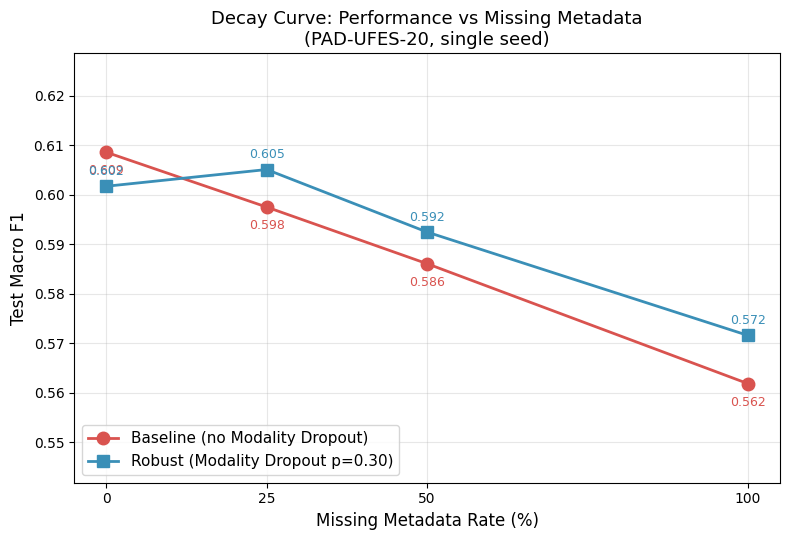

Saved to /kaggle/working/decay_curve_single_seed.png


In [66]:
import matplotlib.pyplot as plt

# X-axis: missing rates in percent
x_values = [0, 25, 50, 100]

# Baseline F1 values (from earlier baseline_results)
baseline_f1_values = []
for rate in [0.0, 0.25, 0.50, 1.0]:
    baseline_f1_values.append(baseline_results[rate]['macro_f1'])

# Robust v2 F1 values (from robust_v2_results)
robust_f1_values = []
for rate in [0.0, 0.25, 0.50, 1.0]:
    robust_f1_values.append(robust_v2_results[rate]['macro_f1'])

# Build the figure
fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(x_values, baseline_f1_values,
        marker='o', linewidth=2, markersize=9,
        color='#d9534f', label='Baseline (no Modality Dropout)')

ax.plot(x_values, robust_f1_values,
        marker='s', linewidth=2, markersize=9,
        color='#3a8fb7', label='Robust (Modality Dropout p=0.30)')

# Labels and styling
ax.set_xlabel('Missing Metadata Rate (%)', fontsize=12)
ax.set_ylabel('Test Macro F1', fontsize=12)
ax.set_title('Decay Curve: Performance vs Missing Metadata\n(PAD-UFES-20, single seed)',
             fontsize=13)
ax.set_xticks(x_values)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=11)

# Add value labels on each point
for x, y in zip(x_values, baseline_f1_values):
    ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(0, -16),
                textcoords='offset points', ha='center', fontsize=9, color='#d9534f')
for x, y in zip(x_values, robust_f1_values):
    ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=9, color='#3a8fb7')

# Y-axis range to keep both lines clearly visible
y_min = min(min(baseline_f1_values), min(robust_f1_values)) - 0.02
y_max = max(max(baseline_f1_values), max(robust_f1_values)) + 0.02
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('/kaggle/working/decay_curve_single_seed.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved to /kaggle/working/decay_curve_single_seed.png")

# **Helper: seed everything**

In [60]:
def set_seed(seed_value):
    """Set all random seeds for reproducibility."""
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
    # Make cuDNN deterministic (slightly slower but more reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# **Helper: train one model and return its decay results**

**Wrapper Function.**

**Train baseline OR robust at a given seed, then evaluate at all 4 missing rates. Returns the decay dict.**

In [62]:
def run_one_experiment(seed_value, train_dropout_prob, val_dropout_prob, run_name):
    """
    Trains one model with given dropout settings and returns its test-time decay curve.
    
    Args:
        seed_value: random seed for model init and training
        train_dropout_prob: 0.0 for baseline, 0.30 for robust
        val_dropout_prob: 0.0 for baseline, 0.50 for robust
        run_name: short identifier (used for checkpoint filename)
    
    Returns:
        dict: {0.0: f1, 0.25: f1, 0.5: f1, 1.0: f1}
    """
    print(f"\n{'='*60}")
    print(f"=== RUN: {run_name}  (seed={seed_value})")
    print(f"=== train_dropout={train_dropout_prob}, val_dropout={val_dropout_prob}")
    print(f"{'='*60}\n")
    
    set_seed(seed_value)
    
    # Build train loader with the given training dropout rate
    train_ds = SkinLesionDataset(
        dataframe=train_df,
        metadata_array=train_meta,
        transform=train_transform,
        modality_dropout_prob=train_dropout_prob,
    )
    train_lo = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True,
    )
    
    # Build val loader with the given val dropout rate
    val_ds = SkinLesionDataset(
        dataframe=val_df,
        metadata_array=val_meta,
        transform=eval_transform,
        modality_dropout_prob=val_dropout_prob,
    )
    val_lo = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
    )
    
    # Build model
    model_obj = MultimodalSkinLesionModel(meta_input_dim=META_DIM, num_classes=NUM_CLASSES).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
    
    trainable = []
    for p in model_obj.parameters():
        if p.requires_grad:
            trainable.append(p)
    
    optimizer = torch.optim.Adam(trainable, lr=1e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=5, factor=0.5
    )
    
    checkpoint_path = f'/kaggle/working/{run_name}.pt'
    
    # Train
    train_model(
        model_obj=model_obj,
        train_loader=train_lo,
        val_loader=val_lo,
        loss_fn=loss_fn,
        optimizer=optimizer,
        scheduler=scheduler,
        max_epochs=50,
        patience=10,
        dev=device,
        checkpoint_path=checkpoint_path,
    )
    
    # Evaluate at all 4 missing rates
    print(f"\n--- Evaluating {run_name} on test set across missing rates ---")
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    eval_model = MultimodalSkinLesionModel(meta_input_dim=META_DIM, num_classes=NUM_CLASSES)
    eval_model.load_state_dict(checkpoint['model_state_dict'])
    eval_model = eval_model.to(device)
    eval_model.eval()
    
    results = {}
    for rate in [0.0, 0.25, 0.50, 1.0]:
        test_ds_r = SkinLesionDataset(
            dataframe=test_df,
            metadata_array=test_meta,
            transform=eval_transform,
            modality_dropout_prob=rate,
        )
        test_lo_r = DataLoader(
            test_ds_r, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=True,
        )
        loss_v, f1_v, acc_v = evaluate(
            eval_model, test_lo_r, loss_fn, device,
            use_image=True, use_meta=True,
        )
        results[rate] = {'f1': f1_v, 'acc': acc_v}
        print(f"  {int(rate*100):>3}% missing:  F1={f1_v:.4f}  Acc={acc_v:.4f}")
    
    return results

# **Run all 6 experiments**

In [63]:
SEEDS = [42, 123, 2024]

# Storage for all results
all_results = {
    'baseline': {},   # seed -> {rate -> {'f1', 'acc'}}
    'robust': {},
}

# === Baseline runs ===
for seed_value in SEEDS:
    run_name = f"baseline_seed{seed_value}"
    results = run_one_experiment(
        seed_value=seed_value,
        train_dropout_prob=0.0,
        val_dropout_prob=0.0,
        run_name=run_name,
    )
    all_results['baseline'][seed_value] = results

# === Robust runs ===
for seed_value in SEEDS:
    run_name = f"robust_seed{seed_value}"
    results = run_one_experiment(
        seed_value=seed_value,
        train_dropout_prob=0.30,
        val_dropout_prob=0.50,
        run_name=run_name,
    )
    all_results['robust'][seed_value] = results

# Save everything to JSON
save_dict = {}
for model_name in ['baseline', 'robust']:
    save_dict[model_name] = {}
    for seed_value in SEEDS:
        save_dict[model_name][str(seed_value)] = {}
        for rate, r in all_results[model_name][seed_value].items():
            save_dict[model_name][str(seed_value)][str(rate)] = r

with open('/kaggle/working/multi_seed_results.json', 'w') as f:
    json.dump(save_dict, f, indent=2)

print("\n\n=== ALL RUNS COMPLETE. Results saved to multi_seed_results.json ===")


=== RUN: baseline_seed42  (seed=42)
=== train_dropout=0.0, val_dropout=0.0

Epoch  1/50  train loss: 1.6600  train F1: 0.2707  val loss: 1.4304  val F1: 0.4731  val Acc: 0.4426  LR: 0.000100  (42s) <-- best
Epoch  2/50  train loss: 1.3180  train F1: 0.4610  val loss: 1.1706  val F1: 0.5252  val Acc: 0.5123  LR: 0.000100  (43s) <-- best
Epoch  3/50  train loss: 1.0578  train F1: 0.5917  val loss: 1.1092  val F1: 0.5239  val Acc: 0.5205  LR: 0.000100  (43s)  (1/10)
Epoch  4/50  train loss: 0.9075  train F1: 0.6131  val loss: 0.9737  val F1: 0.5483  val Acc: 0.5697  LR: 0.000100  (44s) <-- best
Epoch  5/50  train loss: 0.7560  train F1: 0.6779  val loss: 1.0886  val F1: 0.5732  val Acc: 0.5574  LR: 0.000100  (45s) <-- best
Epoch  6/50  train loss: 0.6258  train F1: 0.7422  val loss: 0.9995  val F1: 0.6310  val Acc: 0.6148  LR: 0.000100  (44s) <-- best
Epoch  7/50  train loss: 0.5262  train F1: 0.7569  val loss: 1.0071  val F1: 0.6145  val Acc: 0.6352  LR: 0.000100  (44s)  (1/10)
Epoch  8

# **Aggregate: mean ± std across seeds**

In [64]:
print("=== MULTI-SEED AGGREGATE RESULTS ===\n")
print(f"{'Model':<10}{'Missing':<10}{'Mean F1':>12}{'Std F1':>10}{'Mean Acc':>12}{'Std Acc':>10}")
print("-" * 64)

aggregate = {'baseline': {}, 'robust': {}}

for model_name in ['baseline', 'robust']:
    for rate in [0.0, 0.25, 0.50, 1.0]:
        f1_list = []
        acc_list = []
        for seed_value in SEEDS:
            f1_list.append(all_results[model_name][seed_value][rate]['f1'])
            acc_list.append(all_results[model_name][seed_value][rate]['acc'])
        
        f1_mean = np.mean(f1_list)
        f1_std = np.std(f1_list)
        acc_mean = np.mean(acc_list)
        acc_std = np.std(acc_list)
        
        aggregate[model_name][rate] = {
            'f1_mean': f1_mean,
            'f1_std': f1_std,
            'acc_mean': acc_mean,
            'acc_std': acc_std,
        }
        
        print(f"{model_name:<10}{int(rate*100):>3}%       "
              f"{f1_mean:>12.4f}{f1_std:>10.4f}{acc_mean:>12.4f}{acc_std:>10.4f}")
    print()

# Headline comparison
print("\n=== HEADLINE: BASELINE vs ROBUST (mean ± std) ===")
print(f"{'Missing':<10}{'Baseline F1':>20}{'Robust F1':>20}{'Diff':>12}")
print("-" * 62)
for rate in [0.0, 0.25, 0.50, 1.0]:
    b = aggregate['baseline'][rate]
    r = aggregate['robust'][rate]
    diff = r['f1_mean'] - b['f1_mean']
    print(f"{int(rate*100):>3}%       "
          f"{b['f1_mean']:.4f} ± {b['f1_std']:.4f}    "
          f"{r['f1_mean']:.4f} ± {r['f1_std']:.4f}    "
          f"{diff:>+.4f}")

# Decay comparison
b_decay = aggregate['baseline'][0.0]['f1_mean'] - aggregate['baseline'][1.0]['f1_mean']
r_decay = aggregate['robust'][0.0]['f1_mean'] - aggregate['robust'][1.0]['f1_mean']
print(f"\nBaseline mean decay (0% -> 100%):  {b_decay:+.4f} F1 points")
print(f"Robust   mean decay (0% -> 100%):  {r_decay:+.4f} F1 points")

=== MULTI-SEED AGGREGATE RESULTS ===

Model     Missing        Mean F1    Std F1    Mean Acc   Std Acc
----------------------------------------------------------------
baseline    0%             0.6272    0.0160      0.7017    0.0150
baseline   25%             0.6145    0.0103      0.6842    0.0162
baseline   50%             0.6021    0.0147      0.6674    0.0172
baseline  100%             0.5803    0.0125      0.6287    0.0209

robust      0%             0.5827    0.0038      0.6681    0.0160
robust     25%             0.5775    0.0095      0.6645    0.0199
robust     50%             0.5746    0.0078      0.6594    0.0196
robust    100%             0.5646    0.0146      0.6492    0.0238


=== HEADLINE: BASELINE vs ROBUST (mean ± std) ===
Missing            Baseline F1           Robust F1        Diff
--------------------------------------------------------------
  0%       0.6272 ± 0.0160    0.5827 ± 0.0038    -0.0445
 25%       0.6145 ± 0.0103    0.5775 ± 0.0095    -0.0370
 50%       

# **Single-seed decay curve**

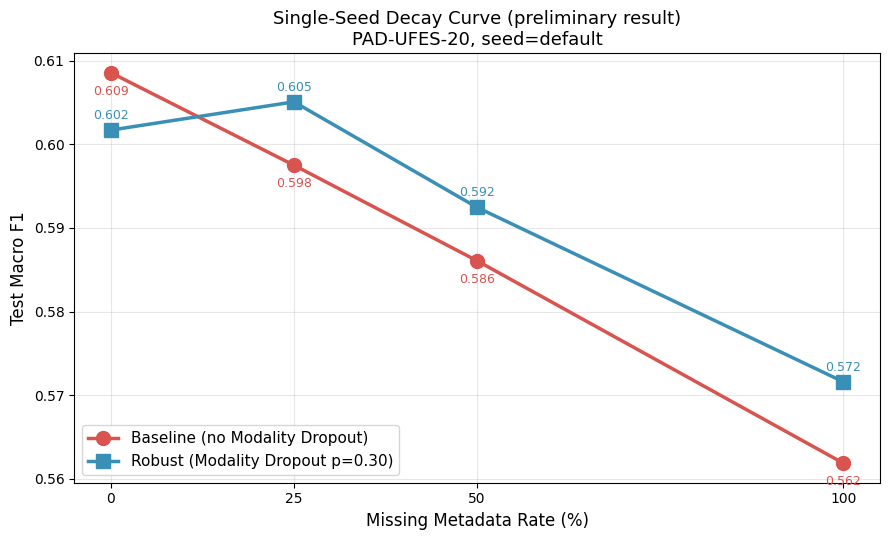

In [68]:
import matplotlib.pyplot as plt

x_values = [0, 25, 50, 100]

# Single-seed baseline (the original run)
baseline_single = [
    baseline_results[0.0]['macro_f1'],
    baseline_results[0.25]['macro_f1'],
    baseline_results[0.50]['macro_f1'],
    baseline_results[1.0]['macro_f1'],
]

# Single-seed robust v2 (the original lucky run)
robust_single = [
    robust_v2_results[0.0]['macro_f1'],
    robust_v2_results[0.25]['macro_f1'],
    robust_v2_results[0.50]['macro_f1'],
    robust_v2_results[1.0]['macro_f1'],
]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(x_values, baseline_single, marker='o', linewidth=2.5, markersize=10,
        color='#d9534f', label='Baseline (no Modality Dropout)')
ax.plot(x_values, robust_single, marker='s', linewidth=2.5, markersize=10,
        color='#3a8fb7', label='Robust (Modality Dropout p=0.30)')

ax.set_xlabel('Missing Metadata Rate (%)', fontsize=12)
ax.set_ylabel('Test Macro F1', fontsize=12)
ax.set_title('Single-Seed Decay Curve (preliminary result)\nPAD-UFES-20, seed=default', fontsize=13)
ax.set_xticks(x_values)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=11)

for x, y in zip(x_values, baseline_single):
    ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(0, -16),
                textcoords='offset points', ha='center', fontsize=9, color='#d9534f')
for x, y in zip(x_values, robust_single):
    ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=9, color='#3a8fb7')

plt.tight_layout()
plt.savefig('/kaggle/working/plot_decay_single.png', dpi=150, bbox_inches='tight')
plt.show()

# **Multi-seed decay curve with error bands**

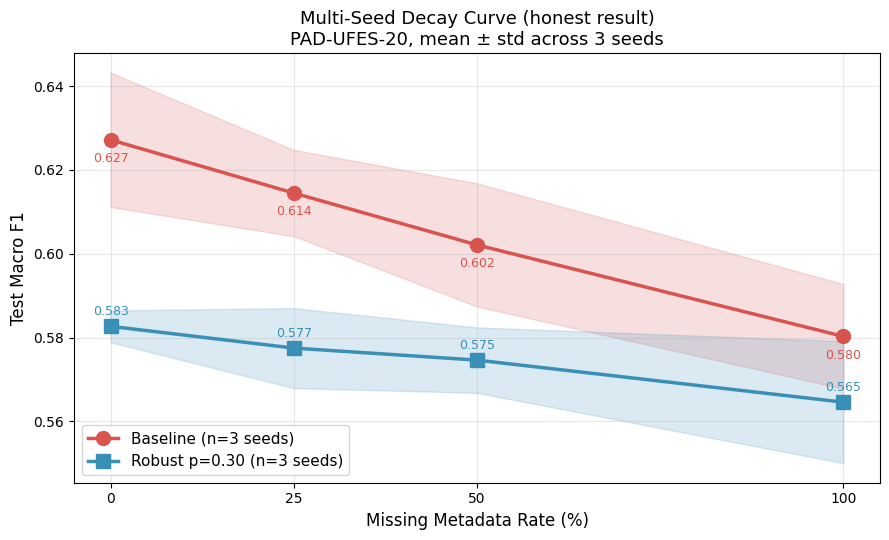

In [69]:
x_values = [0, 25, 50, 100]

# Baseline means and stds from multi-seed run
baseline_means = []
baseline_stds = []
for rate in [0.0, 0.25, 0.50, 1.0]:
    f1_list = [all_results['baseline'][s][rate]['f1'] for s in [42, 123, 2024]]
    baseline_means.append(np.mean(f1_list))
    baseline_stds.append(np.std(f1_list))

# Robust (p=0.30) means and stds
robust_means = []
robust_stds = []
for rate in [0.0, 0.25, 0.50, 1.0]:
    f1_list = [all_results['robust'][s][rate]['f1'] for s in [42, 123, 2024]]
    robust_means.append(np.mean(f1_list))
    robust_stds.append(np.std(f1_list))

baseline_means = np.array(baseline_means)
baseline_stds = np.array(baseline_stds)
robust_means = np.array(robust_means)
robust_stds = np.array(robust_stds)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Baseline with error band
ax.plot(x_values, baseline_means, marker='o', linewidth=2.5, markersize=10,
        color='#d9534f', label='Baseline (n=3 seeds)')
ax.fill_between(x_values, baseline_means - baseline_stds, baseline_means + baseline_stds,
                color='#d9534f', alpha=0.18)

# Robust with error band
ax.plot(x_values, robust_means, marker='s', linewidth=2.5, markersize=10,
        color='#3a8fb7', label='Robust p=0.30 (n=3 seeds)')
ax.fill_between(x_values, robust_means - robust_stds, robust_means + robust_stds,
                color='#3a8fb7', alpha=0.18)

ax.set_xlabel('Missing Metadata Rate (%)', fontsize=12)
ax.set_ylabel('Test Macro F1', fontsize=12)
ax.set_title('Multi-Seed Decay Curve (honest result)\nPAD-UFES-20, mean ± std across 3 seeds', fontsize=13)
ax.set_xticks(x_values)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=11)

for x, y in zip(x_values, baseline_means):
    ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(0, -16),
                textcoords='offset points', ha='center', fontsize=9, color='#d9534f')
for x, y in zip(x_values, robust_means):
    ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=9, color='#3a8fb7')

plt.tight_layout()
plt.savefig('/kaggle/working/plot_decay_multiseed.png', dpi=150, bbox_inches='tight')
plt.show()

# **Image-only vs Metadata-only vs Multimodal**

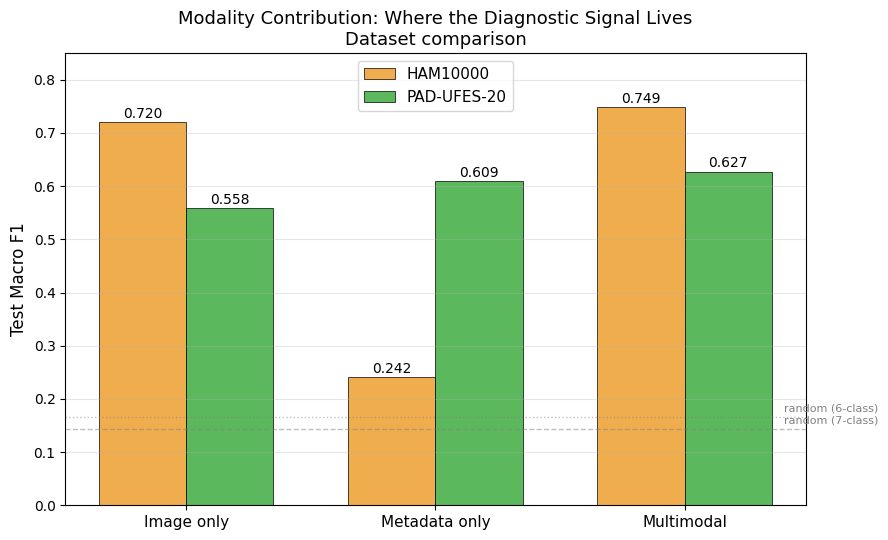

In [70]:
fig, ax = plt.subplots(figsize=(9, 5.5))

# Data from our diagnostic experiments
labels = ['Image only', 'Metadata only', 'Multimodal']
ham10000_values = [0.7204, 0.2416, 0.7490]   # from earlier HAM10000 work
padufes_values  = [0.5582, 0.6094, 0.6272]   # PAD-UFES-20 (multimodal = baseline mean)

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, ham10000_values, width, color='#f0ad4e',
               label='HAM10000', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, padufes_values, width, color='#5cb85c',
               label='PAD-UFES-20', edgecolor='black', linewidth=0.5)

# Value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)
for bar in bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)

ax.axhline(y=1/7, linestyle='--', color='gray', alpha=0.5, linewidth=1)
ax.text(2.4, 1/7 + 0.01, 'random (7-class)', fontsize=8, color='gray')
ax.axhline(y=1/6, linestyle=':', color='gray', alpha=0.5, linewidth=1)
ax.text(2.4, 1/6 + 0.01, 'random (6-class)', fontsize=8, color='gray')

ax.set_ylabel('Test Macro F1', fontsize=12)
ax.set_title('Modality Contribution: Where the Diagnostic Signal Lives\nDataset comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 0.85)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/kaggle/working/plot_modality_contribution.png', dpi=150, bbox_inches='tight')
plt.show()

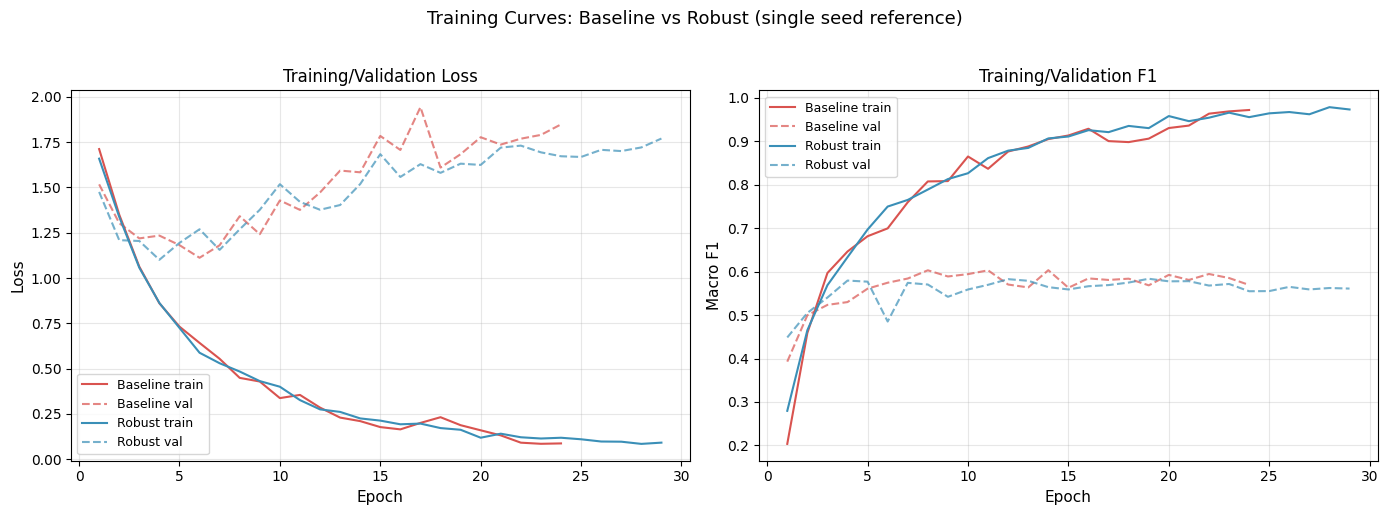

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Loss curves
ax = axes[0]
epochs_b = list(range(1, len(baseline_history['train_loss']) + 1))
epochs_r = list(range(1, len(robust_history_v2['train_loss']) + 1))

ax.plot(epochs_b, baseline_history['train_loss'], color='#d9534f', linestyle='-',
        label='Baseline train', linewidth=1.5)
ax.plot(epochs_b, baseline_history['val_loss'], color='#d9534f', linestyle='--',
        label='Baseline val', linewidth=1.5, alpha=0.7)
ax.plot(epochs_r, robust_history_v2['train_loss'], color='#3a8fb7', linestyle='-',
        label='Robust train', linewidth=1.5)
ax.plot(epochs_r, robust_history_v2['val_loss'], color='#3a8fb7', linestyle='--',
        label='Robust val', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Training/Validation Loss', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: F1 curves
ax = axes[1]
ax.plot(epochs_b, baseline_history['train_f1'], color='#d9534f', linestyle='-',
        label='Baseline train', linewidth=1.5)
ax.plot(epochs_b, baseline_history['val_f1'], color='#d9534f', linestyle='--',
        label='Baseline val', linewidth=1.5, alpha=0.7)
ax.plot(epochs_r, robust_history_v2['train_f1'], color='#3a8fb7', linestyle='-',
        label='Robust train', linewidth=1.5)
ax.plot(epochs_r, robust_history_v2['val_f1'], color='#3a8fb7', linestyle='--',
        label='Robust val', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Macro F1', fontsize=11)
ax.set_title('Training/Validation F1', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves: Baseline vs Robust (single seed reference)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/plot_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

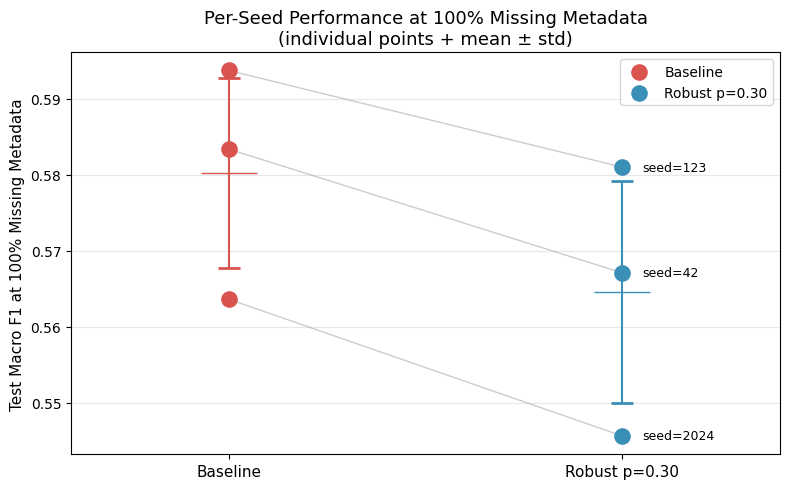

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))

seeds = [42, 123, 2024]
baseline_100 = [all_results['baseline'][s][1.0]['f1'] for s in seeds]
robust_100   = [all_results['robust'][s][1.0]['f1'] for s in seeds]

x_b = [0, 0, 0]
x_r = [1, 1, 1]

ax.scatter(x_b, baseline_100, s=120, color='#d9534f', label='Baseline', zorder=3)
ax.scatter(x_r, robust_100, s=120, color='#3a8fb7', label='Robust p=0.30', zorder=3)

# Lines connecting same-seed pairs
for i, s in enumerate(seeds):
    ax.plot([0, 1], [baseline_100[i], robust_100[i]],
            color='gray', alpha=0.4, linewidth=1, zorder=1)
    ax.annotate(f'seed={s}', xy=(1.05, robust_100[i]), fontsize=9, va='center')

# Mean bars
ax.errorbar([0], [np.mean(baseline_100)], yerr=[np.std(baseline_100)],
            fmt='_', color='#d9534f', markersize=40, capsize=8, capthick=2, zorder=2)
ax.errorbar([1], [np.mean(robust_100)], yerr=[np.std(robust_100)],
            fmt='_', color='#3a8fb7', markersize=40, capsize=8, capthick=2, zorder=2)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Baseline', 'Robust p=0.30'], fontsize=11)
ax.set_ylabel('Test Macro F1 at 100% Missing Metadata', fontsize=11)
ax.set_title('Per-Seed Performance at 100% Missing Metadata\n(individual points + mean ± std)', fontsize=13)
ax.set_xlim(-0.4, 1.4)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/plot_seed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# **Run the 7 ablation experiments**

In [73]:
# Ablation configuration
ABLATION_CONFIGS = [
    # (train_dropout, val_dropout, seeds_list, description)
    (0.10, 0.10, [42, 123, 2024], 'p010'),
    (0.15, 0.15, [42, 123, 2024], 'p015'),
    (0.50, 0.50, [42],             'p050'),  # single seed, ablation upper bound
]

# Add to our existing results
all_results['p010'] = {}
all_results['p015'] = {}
all_results['p050'] = {}

for train_p, val_p, seeds, key in ABLATION_CONFIGS:
    for seed_value in seeds:
        run_name = f"{key}_seed{seed_value}"
        results = run_one_experiment(
            seed_value=seed_value,
            train_dropout_prob=train_p,
            val_dropout_prob=val_p,
            run_name=run_name,
        )
        all_results[key][seed_value] = results

# Save updated results
save_dict = {}
for model_name in all_results.keys():
    save_dict[model_name] = {}
    for seed_value, seed_results in all_results[model_name].items():
        save_dict[model_name][str(seed_value)] = {}
        for rate, r in seed_results.items():
            save_dict[model_name][str(seed_value)][str(rate)] = r

with open('/kaggle/working/full_ablation_results.json', 'w') as f:
    json.dump(save_dict, f, indent=2)

print("\n\n=== ABLATION COMPLETE ===")
print("Results saved to full_ablation_results.json")


=== RUN: p010_seed42  (seed=42)
=== train_dropout=0.1, val_dropout=0.1

Epoch  1/50  train loss: 1.6476  train F1: 0.2733  val loss: 1.4215  val F1: 0.4555  val Acc: 0.4344  LR: 0.000100  (44s) <-- best
Epoch  2/50  train loss: 1.3218  train F1: 0.4458  val loss: 1.2780  val F1: 0.4891  val Acc: 0.5000  LR: 0.000100  (44s) <-- best
Epoch  3/50  train loss: 1.0652  train F1: 0.5598  val loss: 1.1028  val F1: 0.5135  val Acc: 0.4918  LR: 0.000100  (44s) <-- best
Epoch  4/50  train loss: 0.9183  train F1: 0.6017  val loss: 1.0350  val F1: 0.6094  val Acc: 0.6148  LR: 0.000100  (44s) <-- best
Epoch  5/50  train loss: 0.7231  train F1: 0.6761  val loss: 1.1795  val F1: 0.5189  val Acc: 0.5369  LR: 0.000100  (44s)  (1/10)
Epoch  6/50  train loss: 0.6377  train F1: 0.7307  val loss: 1.1876  val F1: 0.5862  val Acc: 0.6434  LR: 0.000100  (45s)  (2/10)
Epoch  7/50  train loss: 0.5607  train F1: 0.7534  val loss: 1.2319  val F1: 0.5799  val Acc: 0.5779  LR: 0.000100  (45s)  (3/10)
Epoch  8/50  

# **Aggregate ablation results**

**Lower dropout rates (p=0.10, p=0.15) with 3 seeds each, plus p=0.50 with 1 seed as upper bound. Validation rate matched to training rate.**

In [74]:
print("=== FULL ABLATION RESULTS (mean ± std) ===\n")
print(f"{'Model':<20}{'0% F1':>15}{'25% F1':>15}{'50% F1':>15}{'100% F1':>15}{'Decay':>12}")
print("-" * 92)

# Map keys to descriptive names
model_display = {
    'baseline': 'Baseline (p=0.00)',
    'p010':     'Robust (p=0.10)',
    'p015':     'Robust (p=0.15)',
    'robust':   'Robust (p=0.30)',
    'p050':     'Robust (p=0.50)',
}

# Display order
display_order = ['baseline', 'p010', 'p015', 'robust', 'p050']

full_aggregate = {}

for model_key in display_order:
    if model_key not in all_results:
        continue
    
    seed_results = all_results[model_key]
    if len(seed_results) == 0:
        continue
    
    row_stats = {}
    for rate in [0.0, 0.25, 0.50, 1.0]:
        f1_list = []
        for seed_value, res in seed_results.items():
            f1_list.append(res[rate]['f1'])
        
        f1_mean = np.mean(f1_list)
        f1_std = np.std(f1_list) if len(f1_list) > 1 else 0.0
        row_stats[rate] = {'mean': f1_mean, 'std': f1_std}
    
    full_aggregate[model_key] = row_stats
    
    # Format row
    decay = row_stats[0.0]['mean'] - row_stats[1.0]['mean']
    
    # If only 1 seed, indicate it
    label = model_display[model_key]
    if len(seed_results) == 1:
        label = label + " *"
    
    print(f"{label:<20}"
          f"{row_stats[0.0]['mean']:.4f}±{row_stats[0.0]['std']:.3f}  "
          f"{row_stats[0.25]['mean']:.4f}±{row_stats[0.25]['std']:.3f}  "
          f"{row_stats[0.5]['mean']:.4f}±{row_stats[0.5]['std']:.3f}  "
          f"{row_stats[1.0]['mean']:.4f}±{row_stats[1.0]['std']:.3f}  "
          f"{decay:>+10.4f}")

print("\n  * = single seed only")

# Compare each ablation row to baseline
print("\n\n=== DIFFERENCE FROM BASELINE (positive = robust wins) ===\n")
print(f"{'Model':<20}{'0% diff':>15}{'25% diff':>15}{'50% diff':>15}{'100% diff':>15}")
print("-" * 80)

if 'baseline' in full_aggregate:
    base = full_aggregate['baseline']
    for model_key in display_order:
        if model_key == 'baseline':
            continue
        if model_key not in full_aggregate:
            continue
        r = full_aggregate[model_key]
        d_0 = r[0.0]['mean'] - base[0.0]['mean']
        d_25 = r[0.25]['mean'] - base[0.25]['mean']
        d_50 = r[0.5]['mean'] - base[0.5]['mean']
        d_100 = r[1.0]['mean'] - base[1.0]['mean']
        
        print(f"{model_display[model_key]:<20}"
              f"{d_0:>+15.4f}{d_25:>+15.4f}{d_50:>+15.4f}{d_100:>+15.4f}")

=== FULL ABLATION RESULTS (mean ± std) ===

Model                         0% F1         25% F1         50% F1        100% F1       Decay
--------------------------------------------------------------------------------------------
Baseline (p=0.00)   0.6272±0.016  0.6145±0.010  0.6021±0.015  0.5803±0.012     +0.0469
Robust (p=0.10)     0.6028±0.014  0.5964±0.016  0.5900±0.015  0.5684±0.026     +0.0344
Robust (p=0.15)     0.5965±0.028  0.5875±0.022  0.5799±0.017  0.5721±0.015     +0.0244
Robust (p=0.30)     0.5827±0.004  0.5775±0.010  0.5746±0.008  0.5646±0.015     +0.0181
Robust (p=0.50) *   0.5417±0.000  0.5398±0.000  0.5385±0.000  0.5385±0.000     +0.0033

  * = single seed only


=== DIFFERENCE FROM BASELINE (positive = robust wins) ===

Model                       0% diff       25% diff       50% diff      100% diff
--------------------------------------------------------------------------------
Robust (p=0.10)             -0.0243        -0.0180        -0.0121        -0.0118
Robust 

# **All-dropout decay curves with error bands**

**Shows how each dropout level trades peak performance for decay flatness.**

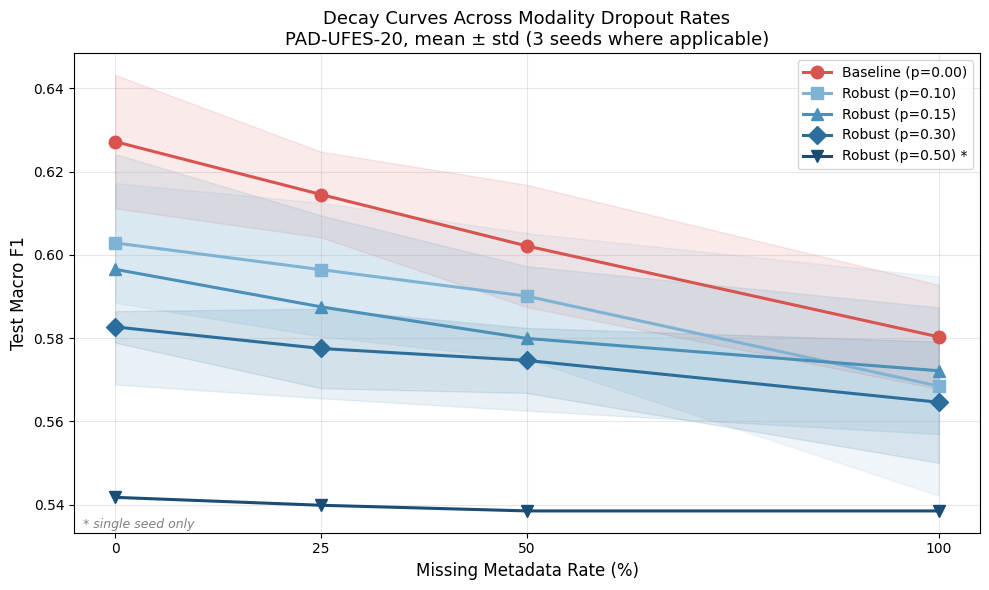

Saved plot1_all_decay_curves.png


In [75]:
import matplotlib.pyplot as plt
import numpy as np

x_values = [0, 25, 50, 100]
rates_keys = [0.0, 0.25, 0.50, 1.0]

# Compute mean and std for each model across seeds
def get_mean_std(model_key, seeds):
    means = []
    stds = []
    for rate in rates_keys:
        f1_list = [all_results[model_key][s][rate]['f1'] for s in seeds]
        means.append(np.mean(f1_list))
        stds.append(np.std(f1_list) if len(f1_list) > 1 else 0.0)
    return np.array(means), np.array(stds)

baseline_mean, baseline_std = get_mean_std('baseline', [42, 123, 2024])
p010_mean, p010_std = get_mean_std('p010', [42, 123, 2024])
p015_mean, p015_std = get_mean_std('p015', [42, 123, 2024])
p030_mean, p030_std = get_mean_std('robust', [42, 123, 2024])
p050_mean, p050_std = get_mean_std('p050', [42])

# Build the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Colors progressing from red (baseline) through blues (more dropout)
colors = ['#d9534f', '#7fb3d5', '#4a90b8', '#2c6e9b', '#1a4d75']
labels = [
    'Baseline (p=0.00)',
    'Robust (p=0.10)',
    'Robust (p=0.15)',
    'Robust (p=0.30)',
    'Robust (p=0.50) *',
]
markers = ['o', 's', '^', 'D', 'v']
means_list = [baseline_mean, p010_mean, p015_mean, p030_mean, p050_mean]
stds_list = [baseline_std, p010_std, p015_std, p030_std, p050_std]

for mean, std, color, label, marker in zip(means_list, stds_list, colors, labels, markers):
    ax.plot(x_values, mean, marker=marker, linewidth=2.2, markersize=9,
            color=color, label=label)
    # Error band only if multiple seeds
    if np.sum(std) > 0:
        ax.fill_between(x_values, mean - std, mean + std, color=color, alpha=0.12)

ax.set_xlabel('Missing Metadata Rate (%)', fontsize=12)
ax.set_ylabel('Test Macro F1', fontsize=12)
ax.set_title('Decay Curves Across Modality Dropout Rates\nPAD-UFES-20, mean ± std (3 seeds where applicable)',
             fontsize=13)
ax.set_xticks(x_values)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

# Footnote
ax.text(0.01, 0.01, '* single seed only', transform=ax.transAxes,
        fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('/kaggle/working/plot1_all_decay_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot1_all_decay_curves.png")

# **Pareto frontier (peak F1 vs decay)**

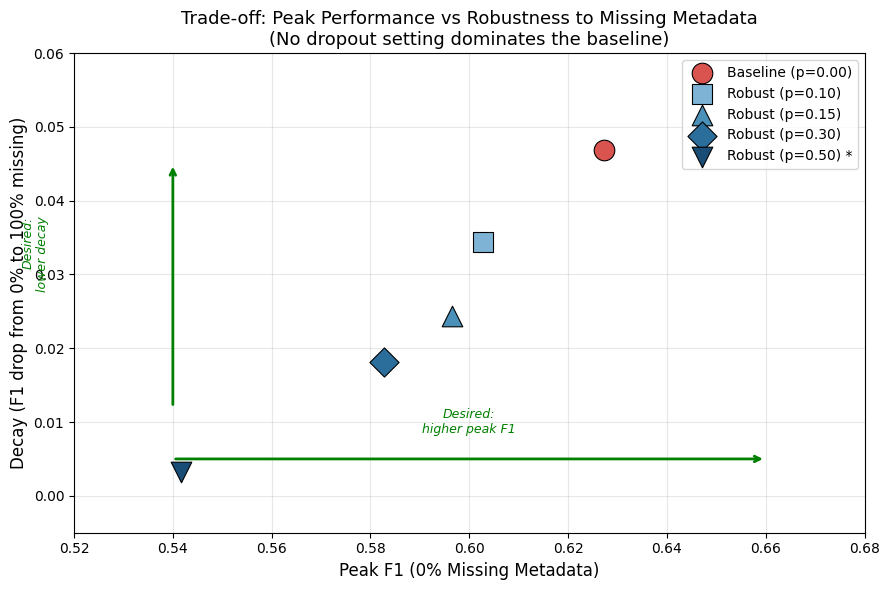

Saved plot2_pareto.png


In [76]:
fig, ax = plt.subplots(figsize=(9, 6))

# Each point: (peak F1 at 0% missing, decay from 0% to 100%)
points_x = [
    baseline_mean[0],
    p010_mean[0],
    p015_mean[0],
    p030_mean[0],
    p050_mean[0],
]
points_y = [
    baseline_mean[0] - baseline_mean[3],
    p010_mean[0] - p010_mean[3],
    p015_mean[0] - p015_mean[3],
    p030_mean[0] - p030_mean[3],
    p050_mean[0] - p050_mean[3],
]

# Plot
for x, y, color, label, marker in zip(points_x, points_y, colors, labels, markers):
    ax.scatter(x, y, s=220, color=color, marker=marker, label=label,
               edgecolor='black', linewidth=0.8, zorder=3)

# Annotation arrows pointing the desired direction
ax.annotate('', xy=(0.66, 0.005), xytext=(0.54, 0.005),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(0.6, 0.0085, 'Desired:\nhigher peak F1', ha='center', fontsize=9,
        color='green', style='italic')

ax.annotate('', xy=(0.54, 0.045), xytext=(0.54, 0.012),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(0.515, 0.028, 'Desired:\nlower decay',
        ha='right', fontsize=9, color='green', style='italic', rotation=90)

ax.set_xlabel('Peak F1 (0% Missing Metadata)', fontsize=12)
ax.set_ylabel('Decay (F1 drop from 0% to 100% missing)', fontsize=12)
ax.set_title('Trade-off: Peak Performance vs Robustness to Missing Metadata\n(No dropout setting dominates the baseline)',
             fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)

# Set axis limits to leave room for annotations
ax.set_xlim(0.52, 0.68)
ax.set_ylim(-0.005, 0.06)

plt.tight_layout()
plt.savefig('/kaggle/working/plot2_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot2_pareto.png")

# **Cross-dataset modality contribution**

**The dataset selection story. Why we tested both datasets.**

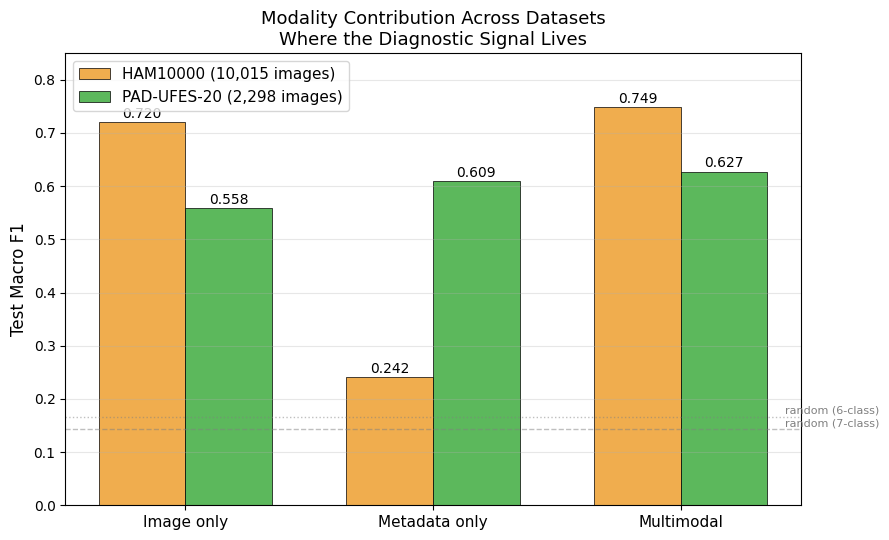

Saved plot3_modality_contribution.png


In [77]:
fig, ax = plt.subplots(figsize=(9, 5.5))

labels_x = ['Image only', 'Metadata only', 'Multimodal']
ham10000_values = [0.7204, 0.2416, 0.7490]
padufes_values  = [0.5582, 0.6094, 0.6272]

x = np.arange(len(labels_x))
width = 0.35

bars1 = ax.bar(x - width/2, ham10000_values, width, color='#f0ad4e',
               label='HAM10000 (10,015 images)', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, padufes_values, width, color='#5cb85c',
               label='PAD-UFES-20 (2,298 images)', edgecolor='black', linewidth=0.5)

for bar in bars1:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)
for bar in bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10)

ax.axhline(y=1/7, linestyle='--', color='gray', alpha=0.5, linewidth=1)
ax.text(2.42, 1/7 + 0.005, 'random (7-class)', fontsize=8, color='gray')
ax.axhline(y=1/6, linestyle=':', color='gray', alpha=0.5, linewidth=1)
ax.text(2.42, 1/6 + 0.005, 'random (6-class)', fontsize=8, color='gray')

ax.set_ylabel('Test Macro F1', fontsize=12)
ax.set_title('Modality Contribution Across Datasets\nWhere the Diagnostic Signal Lives',
             fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels_x, fontsize=11)
ax.set_ylim(0, 0.85)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/kaggle/working/plot3_modality_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot3_modality_contribution.png")

# **Per-class F1 breakdown (baseline vs robust at 100% missing)**

**Which classes break down when metadata is removed. Run inference and compute per-class F1.**

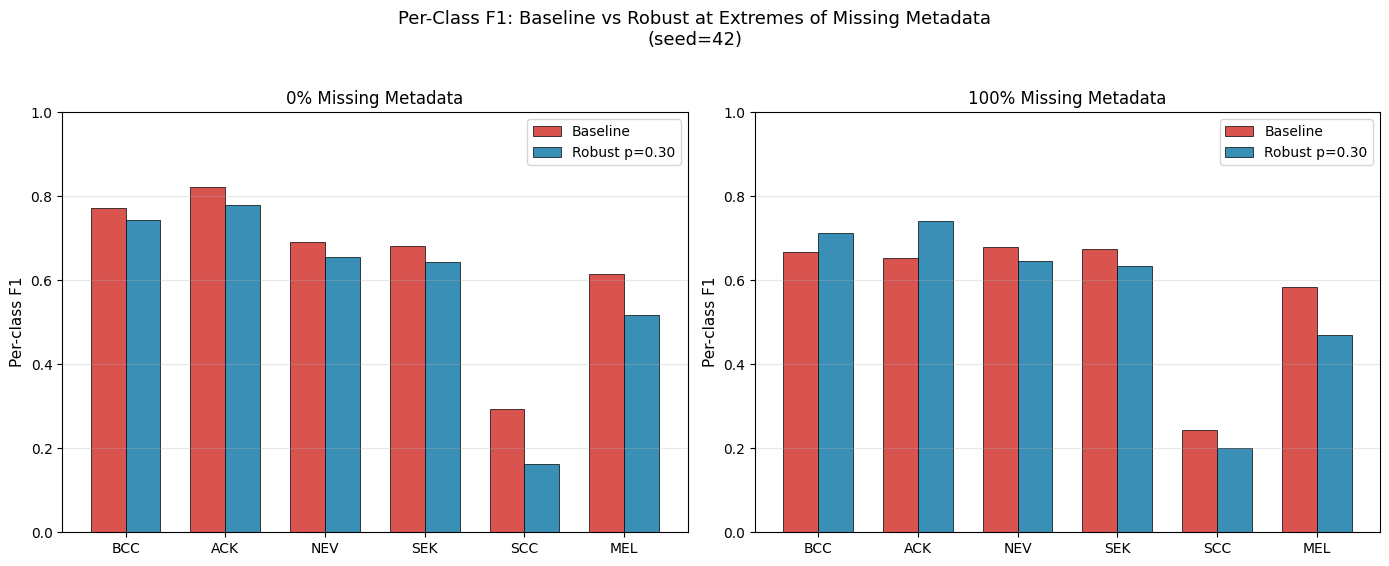


=== Per-class F1 (seed=42) ===
Class      Base 0%   Robust 0%   Base 100%   Robust 100%
BCC         0.7730      0.7440      0.6667        0.7117
ACK         0.8209      0.7778      0.6535        0.7410
NEV         0.6916      0.6555      0.6786        0.6452
SEK         0.6824      0.6429      0.6744        0.6341
SCC         0.2941      0.1622      0.2439        0.2000
MEL         0.6154      0.5161      0.5833        0.4706


In [78]:
from sklearn.metrics import f1_score as f1_per_class_score

# We need per-class F1 for baseline and best-robust model at 0% and 100% missing
# Use seed 42 checkpoints (representative)

def get_per_class_f1(checkpoint_path, missing_rate):
    """Load a checkpoint and compute per-class F1 at the given missing rate."""
    ckpt = torch.load(checkpoint_path, weights_only=False)
    model_obj = MultimodalSkinLesionModel(meta_input_dim=META_DIM, num_classes=NUM_CLASSES)
    model_obj.load_state_dict(ckpt['model_state_dict'])
    model_obj = model_obj.to(device)
    model_obj.eval()
    
    test_ds_r = SkinLesionDataset(
        dataframe=test_df,
        metadata_array=test_meta,
        transform=eval_transform,
        modality_dropout_prob=missing_rate,
    )
    test_lo = DataLoader(test_ds_r, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
    
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, metas, labels in test_lo:
            images = images.to(device)
            metas = metas.to(device)
            logits = model_obj(images, metas)
            preds = torch.argmax(logits, dim=1)
            for p in preds.cpu().tolist():
                all_preds.append(p)
            for l in labels.cpu().tolist():
                all_labels.append(l)
    
    # F1 per class (returns array of length 6)
    per_class = f1_per_class_score(all_labels, all_preds,
                                   labels=[0, 1, 2, 3, 4, 5],
                                   average=None, zero_division=0)
    return per_class

# Use seed 42 checkpoints
baseline_per_class_0 = get_per_class_f1('/kaggle/working/baseline_seed42.pt', 0.0)
baseline_per_class_100 = get_per_class_f1('/kaggle/working/baseline_seed42.pt', 1.0)
robust_per_class_0 = get_per_class_f1('/kaggle/working/robust_seed42.pt', 0.0)
robust_per_class_100 = get_per_class_f1('/kaggle/working/robust_seed42.pt', 1.0)

# Plot — 2 panels: 0% missing and 100% missing
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

x = np.arange(len(class_names))
width = 0.35

# Left panel: 0% missing
ax = axes[0]
ax.bar(x - width/2, baseline_per_class_0, width, color='#d9534f',
       label='Baseline', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, robust_per_class_0, width, color='#3a8fb7',
       label='Robust p=0.30', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=10)
ax.set_ylabel('Per-class F1', fontsize=11)
ax.set_title('0% Missing Metadata', fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Right panel: 100% missing
ax = axes[1]
ax.bar(x - width/2, baseline_per_class_100, width, color='#d9534f',
       label='Baseline', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, robust_per_class_100, width, color='#3a8fb7',
       label='Robust p=0.30', edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=10)
ax.set_ylabel('Per-class F1', fontsize=11)
ax.set_title('100% Missing Metadata', fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Per-Class F1: Baseline vs Robust at Extremes of Missing Metadata\n(seed=42)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/plot4_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the table for the report
print("\n=== Per-class F1 (seed=42) ===")
print(f"{'Class':<8}{'Base 0%':>10}{'Robust 0%':>12}{'Base 100%':>12}{'Robust 100%':>14}")
for i, name in enumerate(class_names):
    print(f"{name:<8}{baseline_per_class_0[i]:>10.4f}{robust_per_class_0[i]:>12.4f}"
          f"{baseline_per_class_100[i]:>12.4f}{robust_per_class_100[i]:>14.4f}")

# **Per-seed scatter across all dropout levels**

**Shows the variance behavior. Confirms the trends aren't seed-specific.**

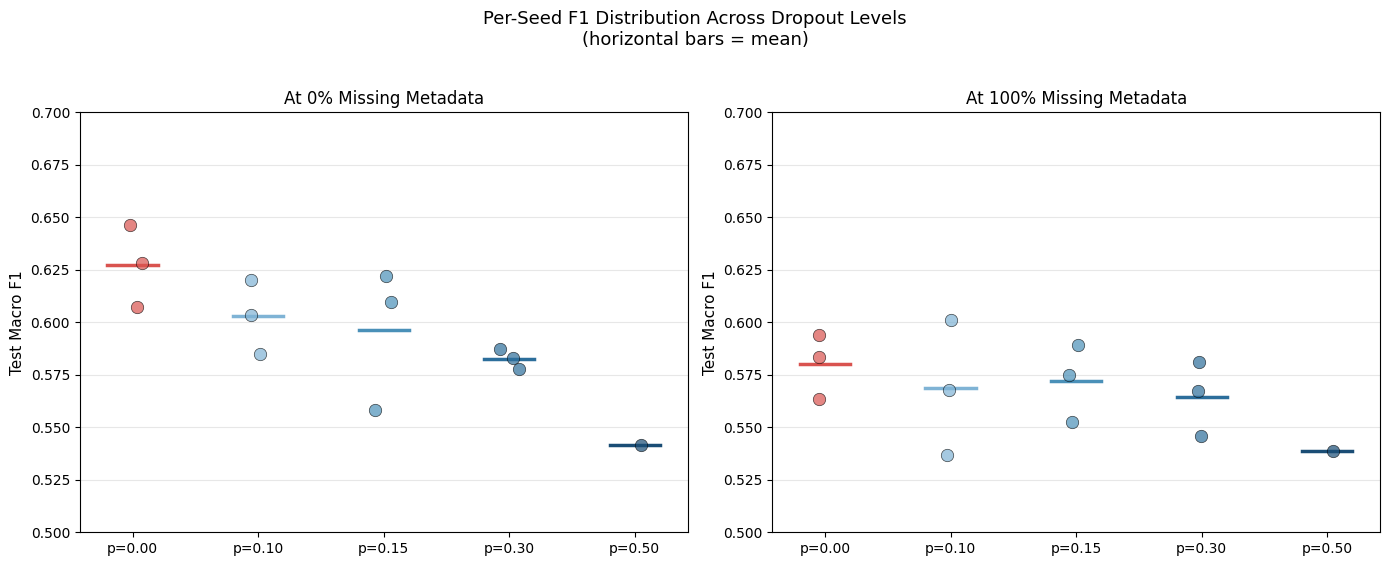

Saved plot5_per_seed_scatter.png


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: 0% missing
ax = axes[0]
all_models = ['baseline', 'p010', 'p015', 'robust', 'p050']
display_labels = ['p=0.00', 'p=0.10', 'p=0.15', 'p=0.30', 'p=0.50']

for i, model_key in enumerate(all_models):
    if model_key not in all_results:
        continue
    seeds_in_model = list(all_results[model_key].keys())
    f1_values = [all_results[model_key][s][0.0]['f1'] for s in seeds_in_model]
    x_jit = [i + np.random.uniform(-0.08, 0.08) for _ in f1_values]
    color = colors[i]
    ax.scatter(x_jit, f1_values, s=80, color=color, alpha=0.7, edgecolor='black',
               linewidth=0.5, zorder=3)
    # Mean line
    mean_f1 = np.mean(f1_values)
    ax.plot([i-0.2, i+0.2], [mean_f1, mean_f1], color=color, linewidth=2.5, zorder=2)

ax.set_xticks(range(len(all_models)))
ax.set_xticklabels(display_labels, fontsize=10)
ax.set_ylabel('Test Macro F1', fontsize=11)
ax.set_title('At 0% Missing Metadata', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.50, 0.70)

# Right: 100% missing
ax = axes[1]
for i, model_key in enumerate(all_models):
    if model_key not in all_results:
        continue
    seeds_in_model = list(all_results[model_key].keys())
    f1_values = [all_results[model_key][s][1.0]['f1'] for s in seeds_in_model]
    x_jit = [i + np.random.uniform(-0.08, 0.08) for _ in f1_values]
    color = colors[i]
    ax.scatter(x_jit, f1_values, s=80, color=color, alpha=0.7, edgecolor='black',
               linewidth=0.5, zorder=3)
    mean_f1 = np.mean(f1_values)
    ax.plot([i-0.2, i+0.2], [mean_f1, mean_f1], color=color, linewidth=2.5, zorder=2)

ax.set_xticks(range(len(all_models)))
ax.set_xticklabels(display_labels, fontsize=10)
ax.set_ylabel('Test Macro F1', fontsize=11)
ax.set_title('At 100% Missing Metadata', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.50, 0.70)

plt.suptitle('Per-Seed F1 Distribution Across Dropout Levels\n(horizontal bars = mean)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/plot5_per_seed_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot5_per_seed_scatter.png")

# **Build all four confusion matrices**

**Load each checkpoint, run inference at the target missing rate, compute confusion matrix, plot as heatmap.**

In [80]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def get_confusion_matrix(checkpoint_path, missing_rate):
    """Load a checkpoint and compute its confusion matrix at the given missing rate."""
    ckpt = torch.load(checkpoint_path, weights_only=False)
    model_obj = MultimodalSkinLesionModel(meta_input_dim=META_DIM, num_classes=NUM_CLASSES)
    model_obj.load_state_dict(ckpt['model_state_dict'])
    model_obj = model_obj.to(device)
    model_obj.eval()
    
    test_ds_r = SkinLesionDataset(
        dataframe=test_df,
        metadata_array=test_meta,
        transform=eval_transform,
        modality_dropout_prob=missing_rate,
    )
    test_lo = DataLoader(test_ds_r, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
    
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, metas, labels in test_lo:
            images = images.to(device)
            metas = metas.to(device)
            logits = model_obj(images, metas)
            preds = torch.argmax(logits, dim=1)
            for p in preds.cpu().tolist():
                all_preds.append(p)
            for l in labels.cpu().tolist():
                all_labels.append(l)
    
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4, 5])
    return cm

# Compute all 4 confusion matrices
print("Computing confusion matrices...")
cm_baseline_0   = get_confusion_matrix('/kaggle/working/baseline_seed42.pt', 0.0)
cm_baseline_100 = get_confusion_matrix('/kaggle/working/baseline_seed42.pt', 1.0)
cm_robust_0     = get_confusion_matrix('/kaggle/working/robust_seed42.pt', 0.0)
cm_robust_100   = get_confusion_matrix('/kaggle/working/robust_seed42.pt', 1.0)

print("Done.")

Computing confusion matrices...
Done.


# **Plot the 4 confusion matrices in a 2x2 grid**

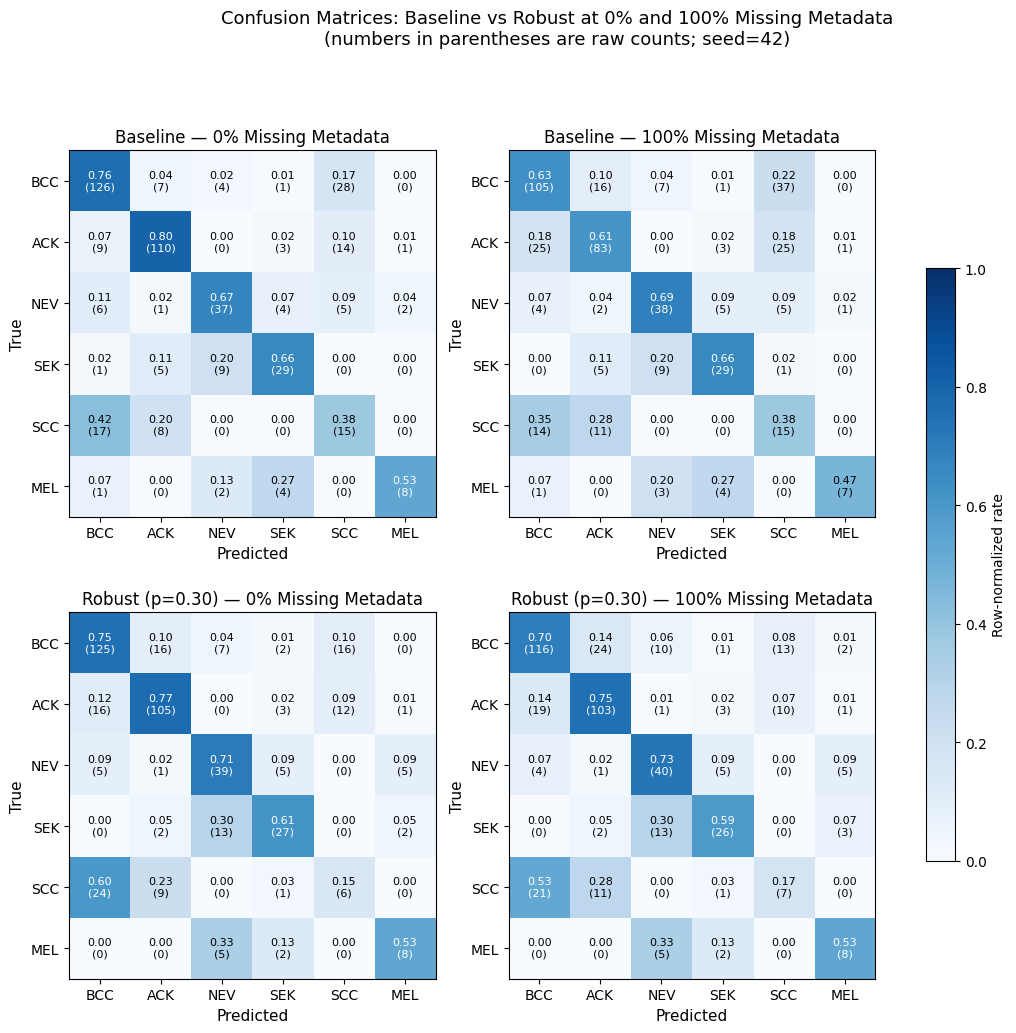

Saved plot6_confusion_matrices.png


In [81]:
def normalize_cm(cm):
    """Row-normalize the confusion matrix (each row sums to 1.0)."""
    cm = cm.astype(float)
    out = np.zeros_like(cm)
    for i in range(cm.shape[0]):
        row_sum = cm[i].sum()
        if row_sum > 0:
            out[i] = cm[i] / row_sum
    return out

# Row-normalize all 4
cm_b0_n = normalize_cm(cm_baseline_0)
cm_b100_n = normalize_cm(cm_baseline_100)
cm_r0_n = normalize_cm(cm_robust_0)
cm_r100_n = normalize_cm(cm_robust_100)

# Build the figure
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

def plot_cm(ax, cm_normalized, cm_raw, title):
    """Plot one confusion matrix heatmap with annotations."""
    im = ax.imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(class_names, fontsize=10)
    ax.set_yticklabels(class_names, fontsize=10)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(title, fontsize=12)
    
    # Annotate each cell with normalized value and raw count
    for i in range(6):
        for j in range(6):
            v_norm = cm_normalized[i, j]
            v_raw = int(cm_raw[i, j])
            # Color text white on dark cells, black on light cells
            text_color = 'white' if v_norm > 0.5 else 'black'
            ax.text(j, i, f'{v_norm:.2f}\n({v_raw})',
                    ha='center', va='center', fontsize=8,
                    color=text_color)
    return im

# Top-left: Baseline, 0% missing
im1 = plot_cm(axes[0, 0], cm_b0_n, cm_baseline_0, 'Baseline — 0% Missing Metadata')
# Top-right: Baseline, 100% missing
im2 = plot_cm(axes[0, 1], cm_b100_n, cm_baseline_100, 'Baseline — 100% Missing Metadata')
# Bottom-left: Robust, 0% missing
im3 = plot_cm(axes[1, 0], cm_r0_n, cm_robust_0, 'Robust (p=0.30) — 0% Missing Metadata')
# Bottom-right: Robust, 100% missing
im4 = plot_cm(axes[1, 1], cm_r100_n, cm_robust_100, 'Robust (p=0.30) — 100% Missing Metadata')

# Colorbar
fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.7, label='Row-normalized rate')

plt.suptitle('Confusion Matrices: Baseline vs Robust at 0% and 100% Missing Metadata\n(numbers in parentheses are raw counts; seed=42)',
             fontsize=13, y=1.0)
plt.savefig('/kaggle/working/plot6_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot6_confusion_matrices.png")

# **Diagonal-only summary (per-class recall)**

# **What percentage of each class did each model correctly predict?**

In [82]:
print("=== Per-class Recall (diagonal of confusion matrix) ===\n")
print(f"{'Class':<8}{'Test n':>8}{'Base 0%':>10}{'Base 100%':>12}"
      f"{'Robust 0%':>12}{'Robust 100%':>14}")
print("-" * 64)

for i, name in enumerate(class_names):
    # n in test set
    n_test = 0
    for j in range(len(test_df)):
        if test_df.loc[j, 'label'] == i:
            n_test += 1
    
    b0 = cm_b0_n[i, i]
    b100 = cm_b100_n[i, i]
    r0 = cm_r0_n[i, i]
    r100 = cm_r100_n[i, i]
    
    print(f"{name:<8}{n_test:>8}{b0:>10.3f}{b100:>12.3f}{r0:>12.3f}{r100:>14.3f}")

# Also compute the impact of metadata removal per class
print("\n=== Recall Drop When Metadata Is Removed (0% → 100%) ===\n")
print(f"{'Class':<8}{'Baseline drop':>16}{'Robust drop':>16}{'Difference':>14}")
print("-" * 54)
for i, name in enumerate(class_names):
    b_drop = cm_b0_n[i, i] - cm_b100_n[i, i]
    r_drop = cm_r0_n[i, i] - cm_r100_n[i, i]
    diff = b_drop - r_drop  # positive = robust degraded less
    print(f"{name:<8}{b_drop:>+16.3f}{r_drop:>+16.3f}{diff:>+14.3f}")

=== Per-class Recall (diagonal of confusion matrix) ===

Class     Test n   Base 0%   Base 100%   Robust 0%   Robust 100%
----------------------------------------------------------------
BCC          166     0.759       0.633       0.753         0.699
ACK          137     0.803       0.606       0.766         0.752
NEV           55     0.673       0.691       0.709         0.727
SEK           44     0.659       0.659       0.614         0.591
SCC           40     0.375       0.375       0.150         0.175
MEL           15     0.533       0.467       0.533         0.533

=== Recall Drop When Metadata Is Removed (0% → 100%) ===

Class      Baseline drop     Robust drop    Difference
------------------------------------------------------
BCC               +0.127          +0.054        +0.072
ACK               +0.197          +0.015        +0.182
NEV               -0.018          -0.018        +0.000
SEK               +0.000          +0.023        -0.023
SCC               +0.000          

# **Per-class recall stability figure**

# **Bar chart showing how much each class's recall drops when metadata is removed. Compares baseline vs robust. Smaller bars = more stable model.**

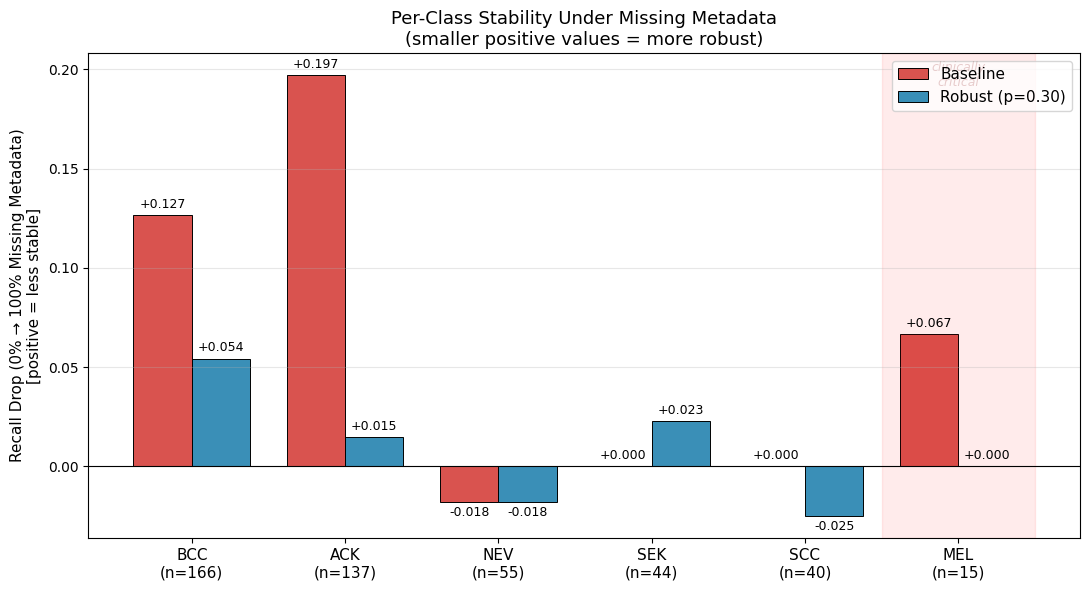

Saved plot7_per_class_stability.png


In [83]:
import matplotlib.pyplot as plt
import numpy as np

# Per-class recall drop when going from 0% missing to 100% missing
# Positive value = recall fell when metadata removed (bad — model became less stable)
# Negative value = recall improved when metadata removed (rare; benefit from regularization)

baseline_drops = []
robust_drops = []

for i in range(6):
    b_drop = cm_b0_n[i, i] - cm_b100_n[i, i]
    r_drop = cm_r0_n[i, i] - cm_r100_n[i, i]
    baseline_drops.append(b_drop)
    robust_drops.append(r_drop)

baseline_drops = np.array(baseline_drops)
robust_drops = np.array(robust_drops)

# Build the figure
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(class_names))
width = 0.38

bars_b = ax.bar(x - width/2, baseline_drops, width, color='#d9534f',
                label='Baseline', edgecolor='black', linewidth=0.7)
bars_r = ax.bar(x + width/2, robust_drops, width, color='#3a8fb7',
                label='Robust (p=0.30)', edgecolor='black', linewidth=0.7)

# Zero line
ax.axhline(y=0, color='black', linewidth=0.8)

# Annotate each bar with its value
for bar in bars_b:
    h = bar.get_height()
    if h >= 0:
        va = 'bottom'
        offset = 3
    else:
        va = 'top'
        offset = -3
    ax.annotate(f'{h:+.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, offset), textcoords='offset points',
                ha='center', va=va, fontsize=9)
for bar in bars_r:
    h = bar.get_height()
    if h >= 0:
        va = 'bottom'
        offset = 3
    else:
        va = 'top'
        offset = -3
    ax.annotate(f'{h:+.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, offset), textcoords='offset points',
                ha='center', va=va, fontsize=9)

# Annotate class sample sizes below x-axis labels
class_n = []
for i in range(6):
    n_test = 0
    for j in range(len(test_df)):
        if test_df.loc[j, 'label'] == i:
            n_test += 1
    class_n.append(n_test)

# Build x labels showing class name + n
x_labels = []
for name, n in zip(class_names, class_n):
    x_labels.append(f"{name}\n(n={n})")

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=11)
ax.set_ylabel('Recall Drop (0% → 100% Missing Metadata)\n[positive = less stable]', fontsize=11)
ax.set_title('Per-Class Stability Under Missing Metadata\n(smaller positive values = more robust)',
             fontsize=13)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Highlight the MEL column with a soft background since it's clinically most important
ax.axvspan(4.5, 5.5, alpha=0.08, color='red')
ax.text(5, ax.get_ylim()[1] * 0.92, 'clinically\ncritical',
        ha='center', fontsize=9, color='darkred', style='italic')

plt.tight_layout()
plt.savefig('/kaggle/working/plot7_per_class_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plot7_per_class_stability.png")